**Librerías**
-

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# **1. Lectura y Selección Variables Muestra**

## **1.1 Lectura Muestra**

In [3]:
data = pd.read_csv("../data/processed.csv")

data.head()

,Unnamed: 0,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,district_pickup,borough_dropoff,district_dropoff,distancia_haversine_km,velocidad_promedio_kmh
0,970802,id3561642,1,2016-03-12 18:25:05,2016-03-12 18:30:38,1,-73.987946,40.743935,-73.979248,40.752480,...,Saturday,18,Saturday,18,Manhattan,105,Manhattan,105,1.199834,12.971179
1,1190423,id3811637,2,2016-04-13 18:17:29,2016-04-13 18:40:49,1,-73.986748,40.755871,-73.949692,40.784519,...,Wednesday,18,Wednesday,18,Manhattan,105,Manhattan,108,4.459326,11.466837
2,538016,id1822735,1,2016-06-25 10:03:28,2016-06-25 10:08:40,1,-73.955673,40.779434,-73.971214,40.786018,...,Saturday,10,Saturday,10,Manhattan,108,Manhattan,107,1.499389,17.300644
3,436657,id2261569,2,2016-04-14 22:03:36,2016-04-14 22:08:34,6,-74.000984,40.731754,-73.991058,40.734970,...,Thursday,22,Thursday,22,Manhattan,102,Manhattan,105,0.909572,10.988118
4,912361,id3546531,1,2016-01-08 08:58:18,2016-01-08 09:11:17,1,-74.015892,40.711498,-74.002022,40.715237,...,Friday,8,Friday,9,Manhattan,101,Manhattan,101,1.240744,5.733860


## **1.2 Selección de Variables**

In [4]:
data.columns

Index(['Unnamed: 0', 'id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'dia_semana_pickup', 'horas_pickup',
       'dia_semana_dropoff', 'horas_dropoff', 'borough_pickup',
       'district_pickup', 'borough_dropoff', 'district_dropoff',
       'distancia_haversine_km', 'velocidad_promedio_kmh'],
      dtype='str')

**Observaciones**
- Unnamed, id, pickup_datetime, dropoff_datetime, pickup_longitude y dropoff_longitude no serán seleccionadas en el análisis, debido a que presentan información irrelevante o ya incluida en otras variables.

In [5]:
del_cols = [
    'Unnamed: 0', 'id', 'pickup_datetime', 'dropoff_datetime','pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude','district_pickup','district_dropoff'
]
df = data.drop(columns=del_cols)

**Observaciones**
- Para darle un mejor uso a las columnas de hora_pickup y hora_dropoff, se creará una columna que mida la franja horaria en la que sucedió el viaje.

In [6]:
bins = [-1, 5, 11, 17, 23]
labels = ["Madrugada", "Mañana", "Tarde", "Noche"]

df["franja_horaria_pickup"] = pd.cut(
    df["horas_pickup"],
    bins=bins,
    labels=labels
)

df["franja_horaria_dropoff"] = pd.cut(
    df["horas_dropoff"],
    bins=bins,
    labels=labels
)

# **2. Clusterización**

## **2.1 Selección Columnas**

In [7]:
num_cols = [
    "distancia_haversine_km",
    "trip_duration",
    "horas_pickup"
]

## **2.2 Estandarización y Codificación**

In [8]:
scaler = StandardScaler()

X_num = pd.DataFrame(
    scaler.fit_transform(df[num_cols]),
    columns=num_cols,
    index=df.index
)

X = X_num

X_scaled = X.to_numpy()

print("Dimensiones de X:", X.shape)

X.head()

Dimensiones de X: (40000, 3)


,distancia_haversine_km,trip_duration,horas_pickup
0,-0.575038,-0.212385,0.689754
1,0.254254,0.167317,0.689754
2,-0.498824,-0.219858,-0.557442
3,-0.648888,-0.224840,1.313352
4,-0.564630,-0.053672,-0.869241


## **2.3 Clusterización distintos k**

In [9]:
output_dir = "../output/role_2"
output_file = os.path.join(output_dir, "kmeans_results.csv")

if not os.path.exists(output_file):

    os.makedirs(output_dir, exist_ok=True)

    k_values = range(2, 15)

    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []

    for k in k_values:

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_scaled)

        # Inercia
        inertias.append(kmeans.inertia_)

        # Silhouette
        silhouette_scores.append(
            silhouette_score(X_scaled, labels)
        )

        # Davies-Bouldin
        davies_bouldin_scores.append(
            davies_bouldin_score(X_scaled, labels)
        )

        # Calinski-Harabasz
        calinski_harabasz_scores.append(
            calinski_harabasz_score(X_scaled, labels)
        )

    results_kmeans = pd.DataFrame({
        "k": list(k_values),
        "inertia": inertias,
        "silhouette": silhouette_scores,
        "davies_bouldin": davies_bouldin_scores,
        "calinski_harabasz": calinski_harabasz_scores
    })

    results_kmeans.to_csv(output_file, index=False)

    print(f"Resultados calculados y guardados en: {output_file}")

else:

    results_kmeans = pd.read_csv(output_file)

    print(f"El archivo ya existe. Resultados cargados desde: {output_file}")

El archivo ya existe. Resultados cargados desde: ../output/role_2/kmeans_results.csv


In [10]:
results_kmeans

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,82864.002909,0.944031,0.098245,17925.342242
1,3,54361.299275,0.408431,0.721424,24147.243976
2,4,29213.870323,0.469167,0.587358,41431.094564
3,5,23102.360339,0.413989,0.674745,41937.627503
4,6,18145.204947,0.434453,0.686153,44900.106761
5,7,15229.652266,0.423041,0.664457,45854.896770
6,8,13094.802473,0.389331,0.705001,46641.927626
7,9,11857.282618,0.381248,0.767809,45591.625448
8,10,10708.431254,0.387809,0.736690,45349.232099
9,11,9840.496271,0.364209,0.752014,44765.966807


## **2.4 Visualización Métricas**

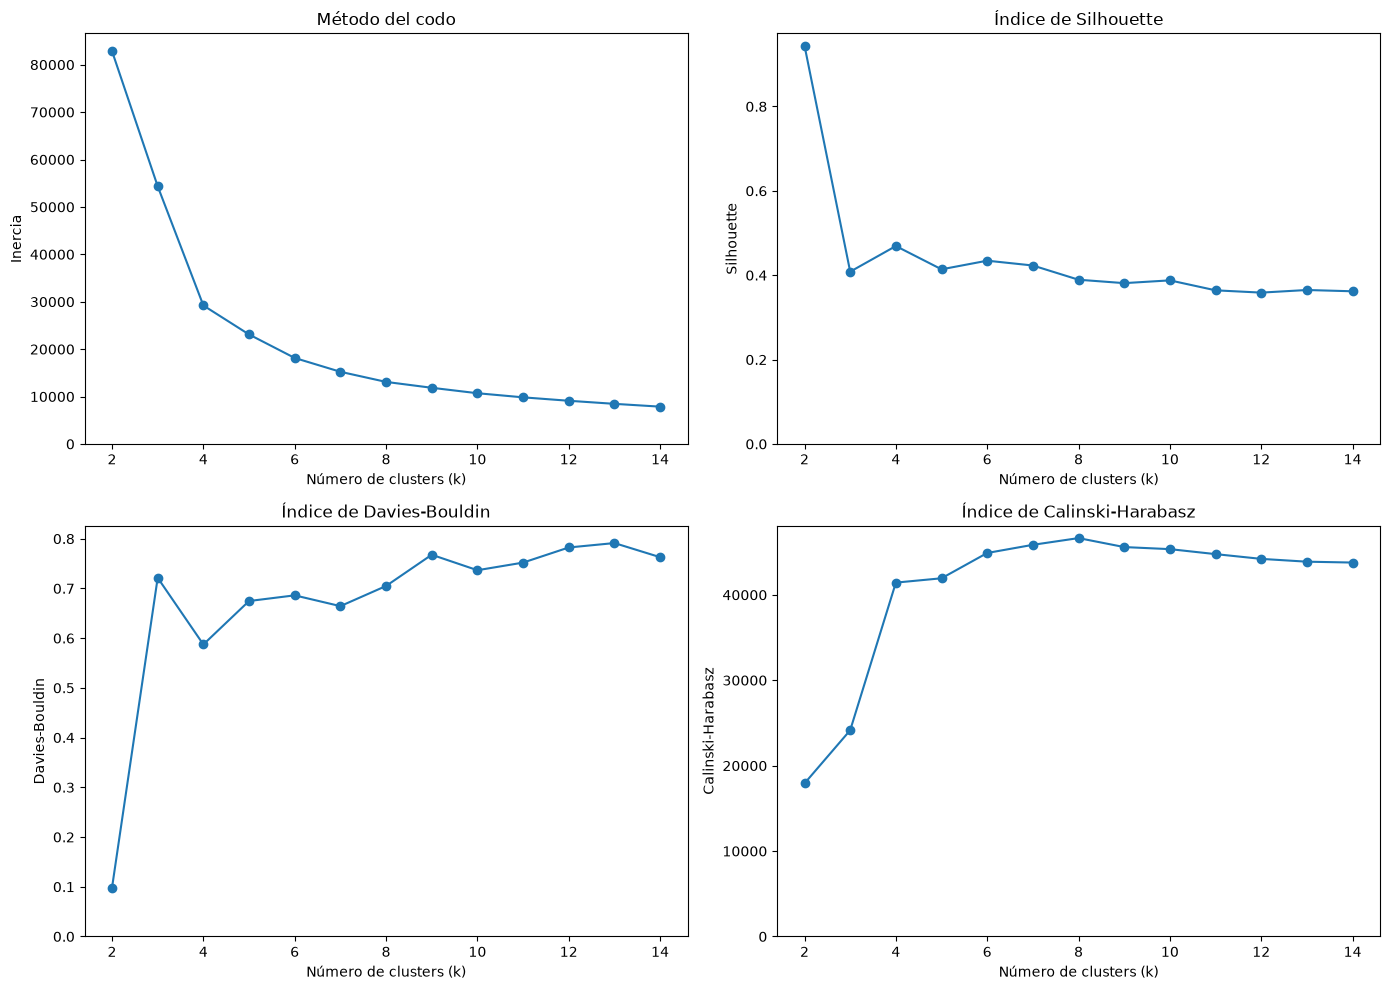

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Método del codo
axes[0, 0].plot(
    results_kmeans["k"],
    results_kmeans["inertia"],
    marker="o"
)
axes[0, 0].set_title("Método del codo")
axes[0, 0].set_xlabel("Número de clusters (k)")
axes[0, 0].set_ylabel("Inercia")
axes[0, 0].set_ylim(bottom=0)

# Silhouette
axes[0, 1].plot(
    results_kmeans["k"],
    results_kmeans["silhouette"],
    marker="o"
)
axes[0, 1].set_title("Índice de Silhouette")
axes[0, 1].set_xlabel("Número de clusters (k)")
axes[0, 1].set_ylabel("Silhouette")
axes[0, 1].set_ylim(bottom=0)

# Davies-Bouldin
axes[1, 0].plot(
    results_kmeans["k"],
    results_kmeans["davies_bouldin"],
    marker="o"
)
axes[1, 0].set_title("Índice de Davies-Bouldin")
axes[1, 0].set_xlabel("Número de clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin")
axes[1, 0].set_ylim(bottom=0)

# Calinski-Harabasz
axes[1, 1].plot(
    results_kmeans["k"],
    results_kmeans["calinski_harabasz"],
    marker="o"
)
axes[1, 1].set_title("Índice de Calinski-Harabasz")
axes[1, 1].set_xlabel("Número de clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz")
axes[1, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

**Observaciones**
- A partir de las métricas analizadas, se considera que $k=4$ es una opción adecuada y coherente en la clusterización.
- El valor del índice de Silhouette en k=4 ($\approx 0.47$) expone una separación moderada entre clases, pero no completamente definida. 
- El valor del índice de Davies Bouldin ($\approx 0.59$) expresa una mejor separación y compactación de los clusteres frente a otros k, a excepción de k=2.
- La inercia disminuye a medida que aumentan los clusteres, a partir del método del codo, se puede estimar que k=4 es una posible selección.
- El índice de Calinskki Harabasz con k=4 expresa una mejor relación entre la dispersión interna y externa de los clusteres.

## **2.5 Análisis de Clústeres**

### **2.5.0 Implementación K-means con $k$ elegido**

In [12]:
def tabla_cont(df, c1, c2):
    tabla_contingencia = pd.crosstab(
        df[c1],
        df[c2]
    )
    return tabla_contingencia
def histograma_kde(df1, df2, columna, bins=30, percentil=100):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    datos1 = df1[columna].dropna()
    datos2 = df2[columna].dropna()

    # Percentil común calculado sobre ambos DataFrames
    if percentil < 100:
        p = pd.concat([datos1, datos2]).quantile(percentil / 100)

        datos1 = datos1[datos1 <= p]
        datos2 = datos2[datos2 <= p]

    # Límites comunes para los histogramas
    limites = np.histogram_bin_edges(
        pd.concat([datos1, datos2]),
        bins=bins
    )

    # ─────────────────────────
    # Gráfico 1: Histograma
    # ─────────────────────────
    axes[0].hist(
        datos1,
        bins=limites,
        alpha=0.5,
        edgecolor="black",
        label="Cluster"
    )

    axes[0].hist(
        datos2,
        bins=limites,
        alpha=0.5,
        edgecolor="black",
        label="Muestra"
    )

    axes[0].set_xlabel(columna)
    axes[0].set_ylabel("Densidad")
    axes[0].set_title(
        f"Histograma  - {columna}"
        + (f" (P{percentil})" if percentil < 100 else "")
    )
    axes[0].legend()

    # ─────────────────────────
    # Gráfico 2: KDE
    # ─────────────────────────
    sns.kdeplot(
        datos1,
        ax=axes[1],
        fill=True,
        alpha=0.4,
        label="Cluster"
    )

    sns.kdeplot(
        datos2,
        ax=axes[1],
        fill=True,
        alpha=0.4,
        label="Muestra"
    )

    axes[1].set_xlabel(columna)
    axes[1].set_ylabel("Densidad")
    axes[1].set_title(
        f"KDE - {columna}"
        + (f" (P{percentil})" if percentil < 100 else "")
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [13]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_final.fit_predict(X_scaled)
df['k_mean_cluster'] = labels_kmeans

df.head()

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
0,1,1,N,5.550000,Saturday,18,Saturday,18,Manhattan,Manhattan,1.199834,12.971179,Noche,Noche,3
1,2,1,N,23.333333,Wednesday,18,Wednesday,18,Manhattan,Manhattan,4.459326,11.466837,Noche,Noche,3
2,1,1,N,5.200000,Saturday,10,Saturday,10,Manhattan,Manhattan,1.499389,17.300644,Mañana,Mañana,0
3,2,6,N,4.966667,Thursday,22,Thursday,22,Manhattan,Manhattan,0.909572,10.988118,Noche,Noche,3
4,1,1,N,12.983333,Friday,8,Friday,9,Manhattan,Manhattan,1.240744,5.733860,Mañana,Mañana,0


In [14]:
# Tamaño de cada cluster
tamaños = df["k_mean_cluster"].value_counts()

# Orden:
# 1. mayor
# 2. menor
# 3. segundo mayor
# 4. tercero mayor
orden = list(tamaños.sort_values(ascending=False).index)

orden_nuevo = [
    orden[0],  # mayor → 0
    orden[-1], # menor → 1
    orden[1],  # segundo mayor → 2
    orden[2]   # tercero mayor → 3
]

cluster_dict = {
    cluster: nuevo
    for nuevo, cluster in enumerate(orden_nuevo)
}

df["k_mean_cluster"] = df["k_mean_cluster"].map(cluster_dict)

### **2.5.1 Cluster 0**

#### **Filtración Registros Cluster**

In [15]:
df_km_c0 = df[df['k_mean_cluster'] == 0]
print("Tamaño Cluster: ", df_km_c0.shape[0])
print(f"Porcentaje del Total: {(df_km_c0.shape[0]/df.shape[0])*100:.2f}%")
df_km_c0.head()

Tamaño Cluster:  21467
Porcentaje del Total: 53.67%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
0,1,1,N,5.550000,Saturday,18,Saturday,18,Manhattan,Manhattan,1.199834,12.971179,Noche,Noche,0
1,2,1,N,23.333333,Wednesday,18,Wednesday,18,Manhattan,Manhattan,4.459326,11.466837,Noche,Noche,0
3,2,6,N,4.966667,Thursday,22,Thursday,22,Manhattan,Manhattan,0.909572,10.988118,Noche,Noche,0
10,2,1,N,22.683333,Thursday,16,Thursday,17,Manhattan,Manhattan,1.815972,4.803452,Tarde,Tarde,0
13,2,1,N,26.333333,Wednesday,19,Wednesday,20,Manhattan,Manhattan,3.618850,8.245480,Noche,Noche,0


**Observaciones**
- El tamaño del cluster ocupa más de la mitad de la muestra analizada.

#### **vendor_id**

In [16]:
df_km_c0['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.538083
1    0.535063
Name: count, dtype: float64

**Observaciones**
- El cluster abarca el 53 % de los viajes con id_vendor = 1 y el 53% de los viajes con id_vendor = 2.

#### **dia_semana**

In [17]:
tabla_cont(df_km_c0,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,3164,0,76,0,0,0,0
Monday,0,2890,0,0,0,30,0
Saturday,0,0,3313,67,0,0,0
Sunday,0,22,0,2500,0,0,0
Thursday,55,0,0,0,3217,0,0
Tuesday,0,0,0,0,0,2977,29
Wednesday,0,0,0,0,40,0,3087


In [18]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- No se observa algun patrón concreto en el cluster al analizarlo con esta variable, aunque representa por lo menos la mitad de cada relación dia_pickup-dia_dropoff en la tabla de contingencia.

#### **borough**

In [19]:
tabla_cont(df_km_c0,"borough_pickup","borough_dropoff")

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens
borough_pickup,,,,,
Bronx,8,0,0,8,0
Brooklyn,0,221,0,67,8
Externo,0,1,6,3,0
Manhattan,39,624,13,19794,254
Queens,6,19,5,162,229


In [20]:
tabla_cont(df,"borough_pickup","borough_dropoff")

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster logra captar más de la mitad de los viajes Manhattan-Manhattan y poco menos de la mitad de los viajes Manhattan-Brookly.
- El cluster excluye todo viaje que haya finalizado en Staten Island.

#### **store_and_fwd_flag**

In [21]:
df_km_c0['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.536914
Y    0.495690
Name: count, dtype: float64

In [22]:
df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    39768
Y      232
Name: count, dtype: int64

**Observaciones**
- El cluster abarca alrededor de la mitad de los casos en los que no se confirmo que el registro se había enviado al servidor y alrededor de la mitad en los que si se almaceno localmente previo al envio. 
- La proporción de viajes almacenados localmente es muy inferior a los que no fueron almacenados, el hecho de que este cluster almacene alrededor del 50% nos puede dar un aspecto diferenciador con respecto a otros clusteres.

#### **franja horaria**

In [23]:
tabla_cont(df_km_c0,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Tarde,Noche
franja_horaria_pickup,,,
Tarde,0,8398,410
Noche,319,0,12340


In [24]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- El cluster solo abarca los viajes que iniciaron en una franja de tarde o noche.
- El cluster abarca más del 90% de todos los viajes que se realizaron en la franja noche-noche.
- El cluster abarca el 90% de todos los viajes que se realizaron en la franja tarde-tarde
- El cluster capta más del 80% de los viajes que se realizaron en las franjas noche-madrugada y alcanza un 70% de todos los viajes que se realizaron en la franja tarde-noche.

#### **passenger_count**

In [25]:
df_km_c0['passenger_count'].value_counts()

passenger_count
1    14926
2     3283
5     1182
3      951
6      673
4      452
Name: count, dtype: int64

In [26]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El cluster representa al menos la mitad de los viajes de la muestra para cada número de pasajeros.

#### **distancia_harvesine**

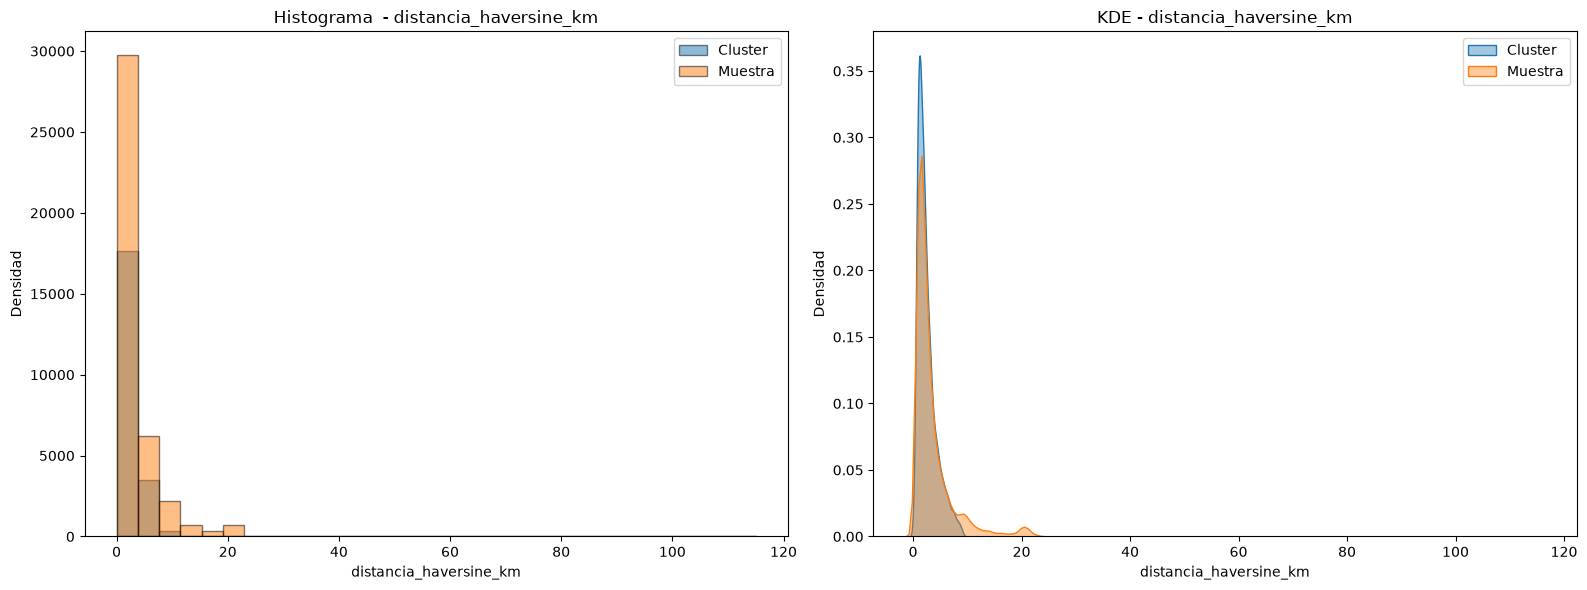

In [27]:
histograma_kde(df_km_c0,df,'distancia_haversine_km')

In [28]:
print("Min: ", df_km_c0['distancia_haversine_km'].min())
print("Max: ", df_km_c0['distancia_haversine_km'].max())

Min:  0.0008483499643316
Max:  9.468470022640146


In [29]:
df_km_c0[df_km_c0['distancia_haversine_km'] < 0.01].shape

(9, 15)

**Observaciones**
- El cluster abarca en su mayoría los viajes que poseen distancias inferiores a los 9.5km de la distancia haversine, es decir, no posee distancias extremadamente elevadas. No obstante, logra incluir observaciones con distancias extremadamennte cortas.

#### **velocidad_promedio_kmh**

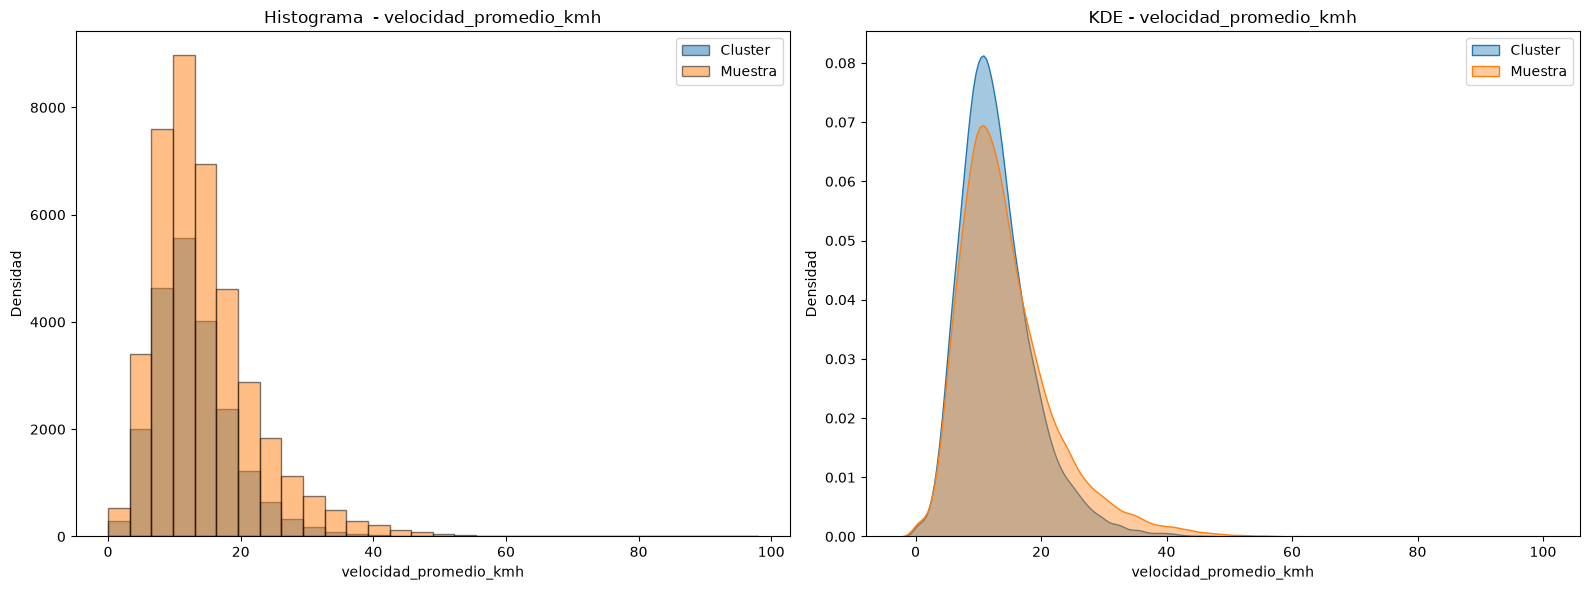

In [30]:
histograma_kde(df_km_c0,df,'velocidad_promedio_kmh')

In [31]:
print("Min: ", df_km_c0['velocidad_promedio_kmh'].min())
print("Max: ", df_km_c0['velocidad_promedio_kmh'].max())

Min:  0.0024749269623939
Max:  77.48337860244432


**Observaciones**
- El cluster abarca distancias muy cortas, la mayor parte de las velocidades se encuentran en menos de los 20km, aunque posee ciertas velocidades extremas (muy grandes como muy pequeñas)

#### **trip_duration**

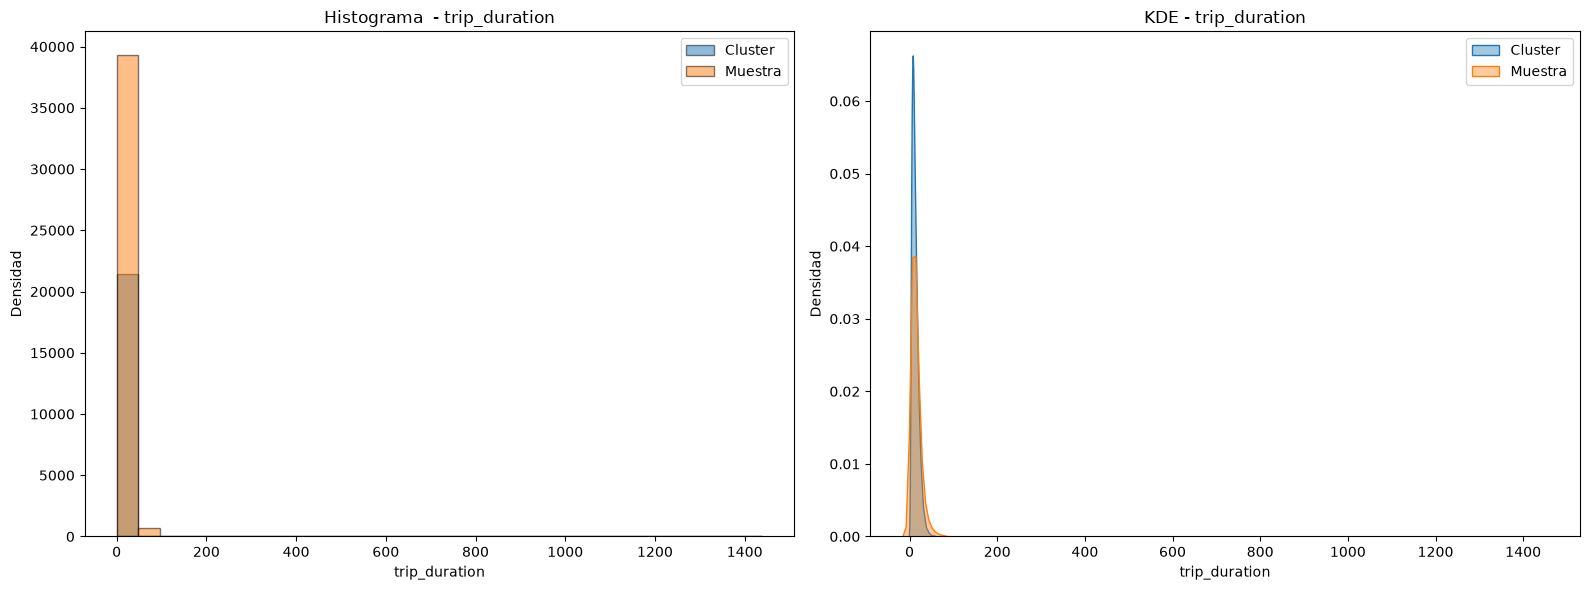

In [32]:
histograma_kde(df_km_c0,df,'trip_duration')

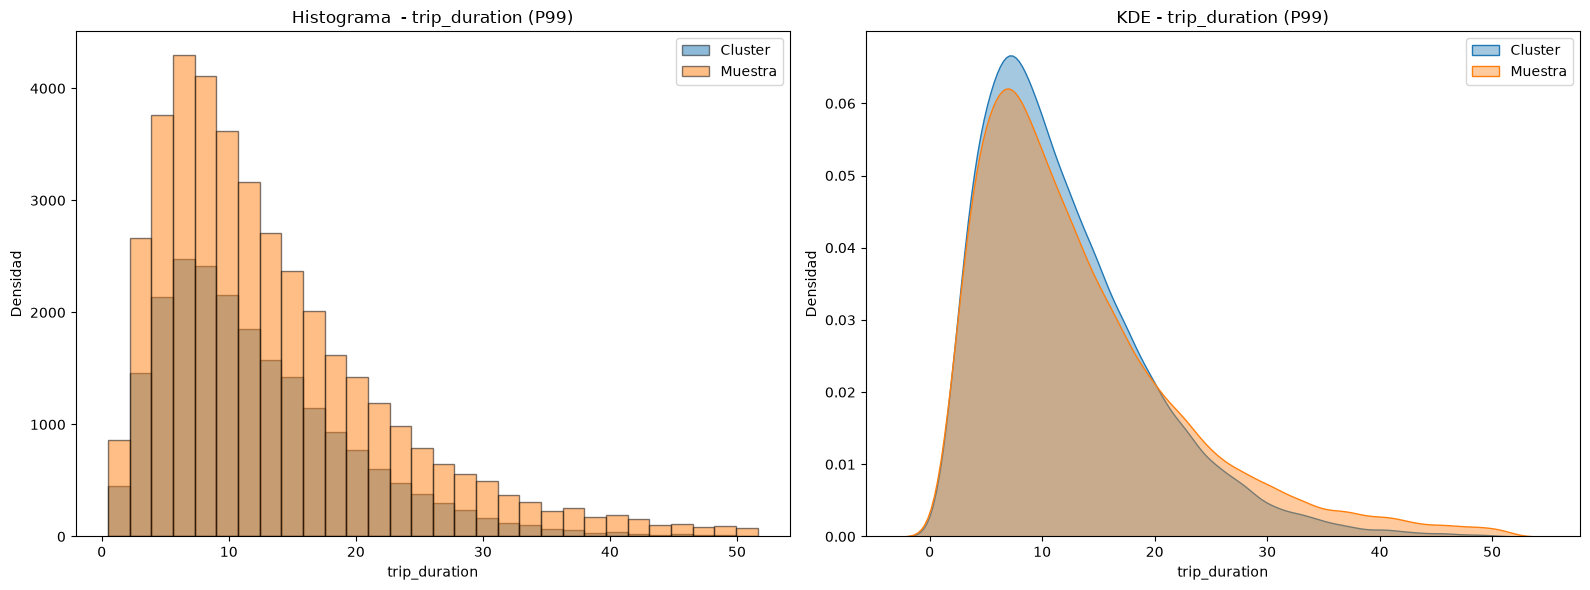

In [33]:
histograma_kde(df_km_c0,df,'trip_duration',30,99)

In [34]:
print("Min: ", df_km_c0['trip_duration'].min())
print("Max: ", df_km_c0['trip_duration'].max())

Min:  0.5
Max:  215.15


In [35]:
df_km_c0[df_km_c0['trip_duration'] > 60].shape

(20, 15)

**Observaciones**
- La mayor concentración de viajes del cluster son inferiores a los 25 minutos, aunque posee algunos viajes con duraciones superiores a 1 hora.

### **2.5.2 Cluster 1**

#### **Filtración de Viajes**

In [36]:
df_km_c1 = df[df['k_mean_cluster'] == 1]
print("Tamaño Cluster: ", df_km_c1.shape[0])
print(f"Porcentaje del Total: {(df_km_c1.shape[0]/df.shape[0])*100:.2f}%")
df_km_c1.head()

Tamaño Cluster:  42
Porcentaje del Total: 0.10%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2882,2,2,N,1416.866667,Thursday,23,Friday,23,Manhattan,Manhattan,1.339752,0.056734,Noche,Noche,1
3090,2,1,N,1438.783333,Thursday,11,Friday,11,Manhattan,Manhattan,5.427887,0.226353,Mañana,Mañana,1
4831,2,1,N,1333.233333,Tuesday,9,Wednesday,7,Queens,Manhattan,3.355197,0.150995,Mañana,Mañana,1
5000,2,5,N,1429.716667,Thursday,11,Friday,11,Manhattan,Manhattan,1.767160,0.074161,Mañana,Mañana,1
5133,2,1,N,1386.166667,Saturday,23,Sunday,22,Manhattan,Manhattan,2.088489,0.090400,Noche,Noche,1


**Observaciones**
- El cluster abarca una porción casi insignificante de los datos, se especula que pueden ser viajes anómalos.

#### **vendor_id**

In [37]:
df_km_c1['vendor_id'].value_counts()

vendor_id
2    41
1     1
Name: count, dtype: int64

**Observaciones**
- El cluster en su mayoria solo registra viajes del vendedor 2

#### **dia_semana**

In [38]:
tabla_cont(df_km_c1,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,0,0,6,0,0,0,0
Monday,0,0,0,0,0,4,0
Saturday,0,0,1,9,0,0,0
Sunday,0,4,0,0,0,0,0
Thursday,10,0,0,0,0,0,0
Tuesday,0,0,0,0,0,0,4
Wednesday,0,0,0,0,3,0,1


In [39]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- La mayor parte de los viajes del cluster suelen abarcar dos días.

#### **borough**

In [40]:
tabla_cont(df_km_c1,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens
borough_pickup,,,,,
Bronx,1,0,0,0,0
Brooklyn,0,1,0,0,0
Manhattan,0,1,1,32,3
Queens,0,0,0,3,0


In [41]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- La mayor cantidad de los viajes del cluster son Manhattan-Manhattan.

#### **store_and_fwd_flag**

In [42]:
df_km_c1['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    42
Name: count, dtype: int64

**Observaciones**
- Ningún viaje del cluster se almaceno localmente antes de enviarse al servidor.

#### **franja_horaria**

In [43]:
tabla_cont(df_km_c1,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,7,0,1,1
Mañana,0,7,0,0
Tarde,0,0,9,0
Noche,0,0,1,16


{'whiskers': [<matplotlib.lines.Line2D at 0x722c8f001d30>,
 'caps': [<matplotlib.lines.Line2D at 0x722c8f0007d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x722c8f000ef0>],
 'medians': [<matplotlib.lines.Line2D at 0x722c8f0006b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x722c8f001310>],
 'means': []}

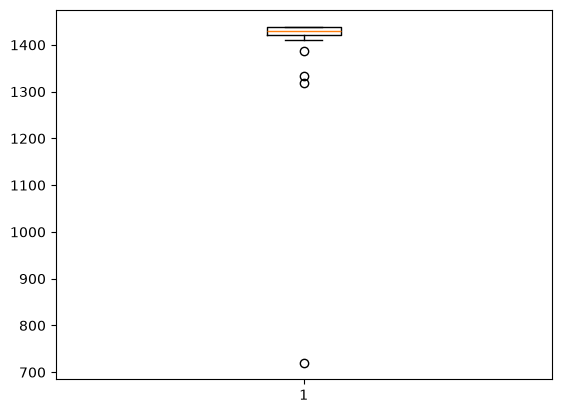

In [44]:
plt.boxplot(df_km_c1['trip_duration'])

**Observaciones**
- No se toma en cuenta franja horaria, porque varios de estos viajes duraron más de un día. Por consiguiente, el análisis de la franja horaria no brindaría información completamente objetiva.

#### **passenger_count**

In [45]:
df_km_c1['passenger_count'].value_counts()

passenger_count
1    30
2     6
5     4
3     1
6     1
Name: count, dtype: int64

In [46]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- La mayoría de los viajes del cluster tienen un pasajero.

#### **distancia_haversine**

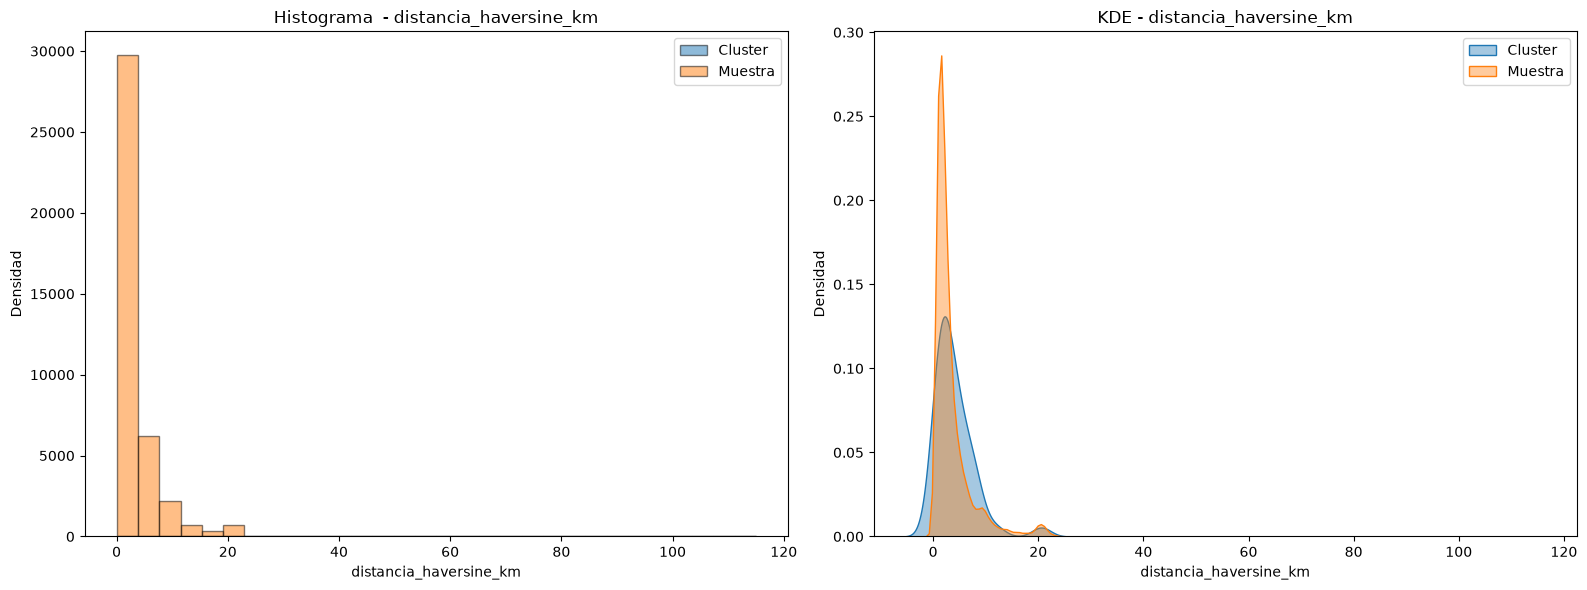

In [47]:
histograma_kde(df_km_c1,df,'distancia_haversine_km')

**Observaciones**
- La mayor cantidad de observaciones del cluster no superan los 17 kilómetros de distancia.

#### **velocidad_promedio_kmh**

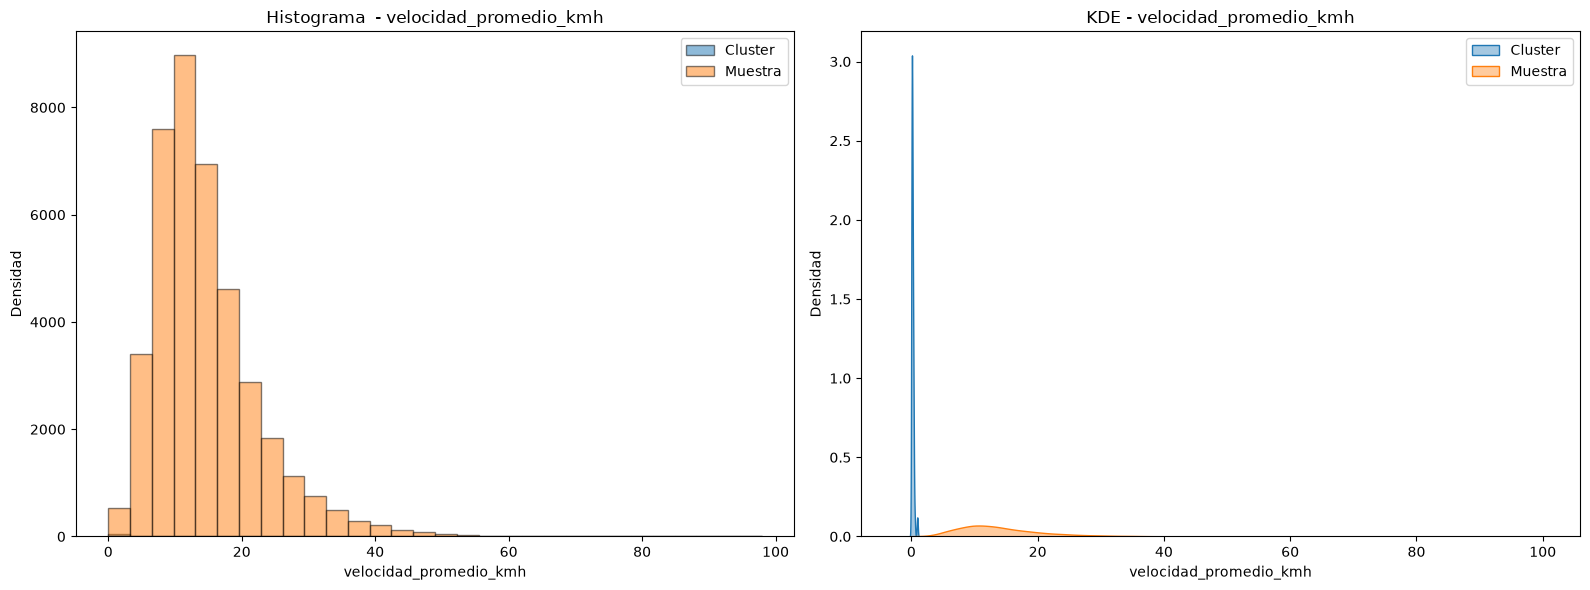

In [48]:
histograma_kde(df_km_c1,df,'velocidad_promedio_kmh')

**Observaciones**
- La velocidad promedio de los viajes del cluster es muy cercana a cero, esto difiere en gran manera de la distribución general.
- Es importante recordar que la velocidad promedio se definio como distancia/tiempo, por lo que no implica que el carro estuviera moviendose a una velocidad tan baja, sino que se demoro mucho tiempo en completar el viaje.

#### **trip_duration**

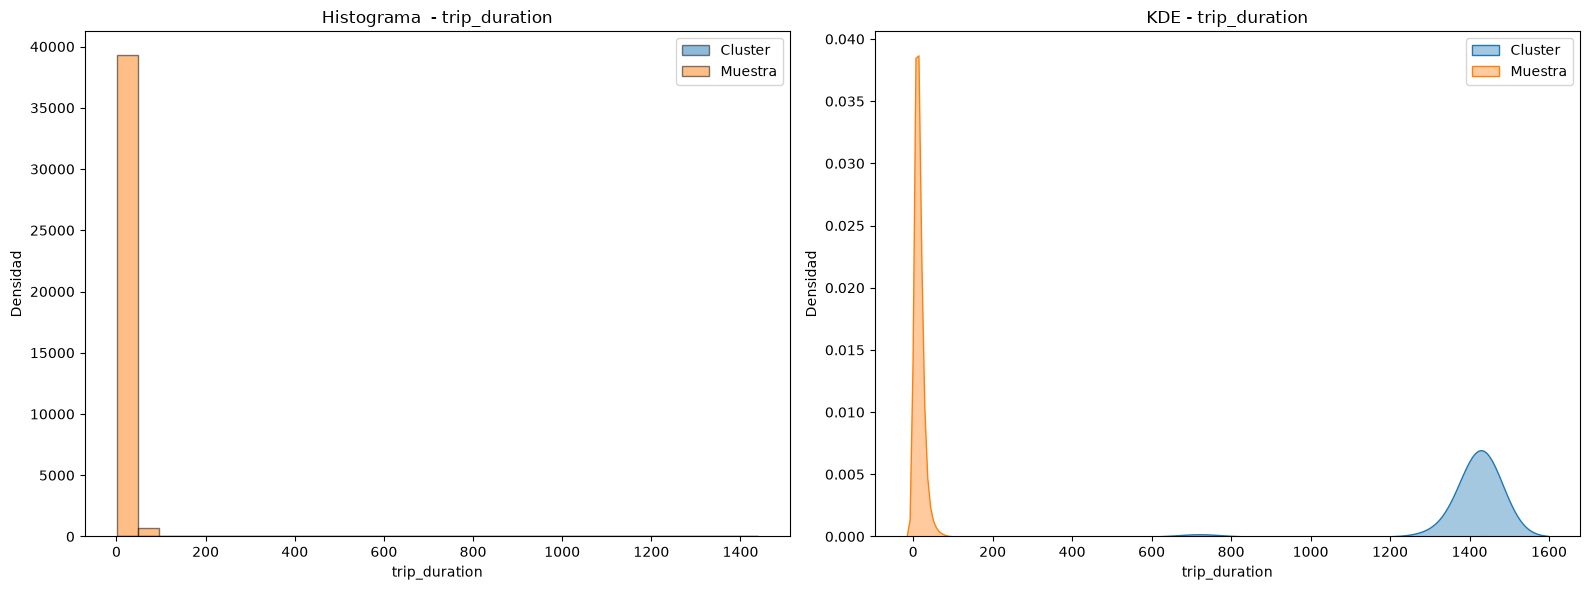

In [49]:
histograma_kde(df_km_c1,df,'trip_duration')

**Observaciones**
- Los viajes del cluster se caracterizan por tener tiempos de duración de viaje extremadamente elevados en contraste a los de la muestra en general.

### **2.5.3 Cluster 2**

#### **Filtración Viajes del Cluster**

In [50]:
df_km_c2 = df[df['k_mean_cluster'] == 2]
print("Tamaño Cluster: ", df_km_c2.shape[0])
print(f"Porcentaje del Total: {(df_km_c2.shape[0]/df.shape[0])*100:.2f}%")
df_km_c2.head()

Tamaño Cluster:  15302
Porcentaje del Total: 38.26%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2,1,1,N,5.200000,Saturday,10,Saturday,10,Manhattan,Manhattan,1.499389,17.300644,Mañana,Mañana,2
4,1,1,N,12.983333,Friday,8,Friday,9,Manhattan,Manhattan,1.240744,5.733860,Mañana,Mañana,2
5,1,1,N,3.983333,Wednesday,6,Wednesday,6,Manhattan,Manhattan,0.803794,12.107363,Mañana,Mañana,2
6,1,1,N,9.433333,Thursday,7,Thursday,7,Manhattan,Manhattan,1.874589,11.923179,Mañana,Mañana,2
7,1,1,N,18.200000,Monday,10,Monday,10,Manhattan,Manhattan,3.976712,13.110039,Mañana,Mañana,2


#### **vendor_id**

In [51]:
df_km_c2['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.376382
1    0.389610
Name: count, dtype: float64

**Observaciones**
- El cluster 2 posee el 38% de los viajes que tienen el proveedor 2 y el 39% aproximadamente de los viajes que posee el proveedor 1.

#### **dia_semana**

In [52]:
tabla_cont(df_km_c2,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,2386,0,0,0,0,0,0
Monday,0,1871,0,0,0,0,0
Saturday,0,0,2350,0,0,0,0
Sunday,0,0,0,2369,0,0,0
Thursday,0,0,0,0,2156,0,0
Tuesday,0,0,0,0,0,2032,0
Wednesday,0,0,0,0,0,0,2138


In [53]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- El cluster se caracteriza por abarcar únicamente viajes que se realizaron en el mismo día.

#### **borough**

In [54]:
tabla_cont(df_km_c2,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens
borough_pickup,,,,,
Bronx,10,0,0,5,0
Brooklyn,0,220,0,131,10
Externo,0,0,5,4,0
Manhattan,45,473,15,13632,377
Queens,5,25,2,123,220


In [55]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster 2 abarca una parte importante de los viajes que se inician en Manhattan y terminan enss Brooklyn, Manhattan o Queens, aunque el cluster 0 posee una mayor proporción en estos.
- El cluster 2 abarca casi la mitad o más de la mitad de los viajes que inician en Brooklyn.

#### **store_and_fwd_flag**

In [56]:
df_km_c2['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.382946
Y    0.314655
Name: count, dtype: float64

**Observaciones**
- El cluster 2 abarca aproximadamente el 38% de todos los viajes que no se registraron localmente previo a ser enviados al servidor y el 31% de todos los viajes que si fueron registrados localmente antes de ser enviados.

#### **franja_horaria**

In [57]:
tabla_cont(df_km_c2,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde
franja_horaria_pickup,,,
Madrugada,4319,60,0
Mañana,0,8761,399
Tarde,0,0,1763


In [58]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- El cluster abarca una porción grande de los viajes que se realizaron en las franjas madrugada-madrugad, mañana-mañana, madrugada-mañana y mañana-tarde.
- El cluster dos posee una cantidad pequeña (pero no insignificante) de viajes en la franja horaria tarde-tarde en contraste al cluster 0

#### **passanger_count**

In [59]:
df_km_c2['passenger_count'].value_counts()

passenger_count
1    11270
2     1926
5      797
3      584
6      479
4      246
Name: count, dtype: int64

In [60]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El cluster 2 posee poco más de 1/3 de los viajes para cada número de pasajeros.

#### **distancia_haversine_km**

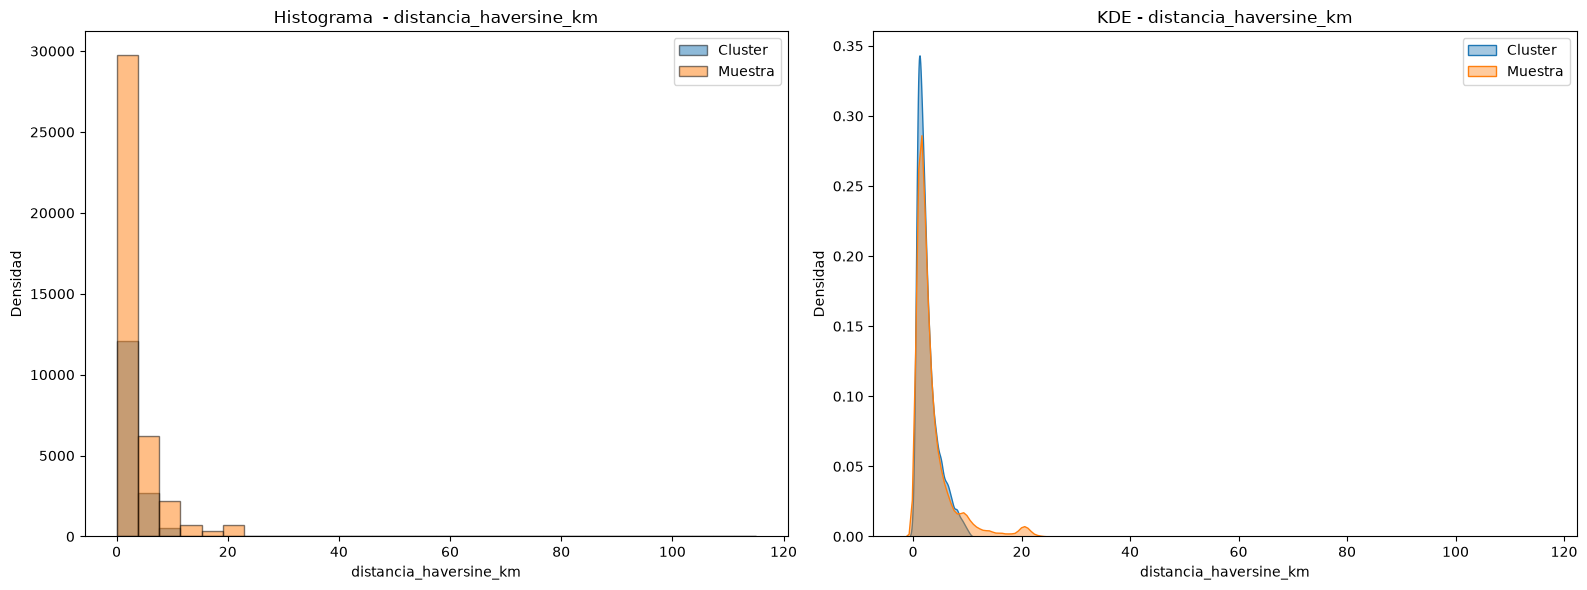

In [61]:
histograma_kde(df_km_c2,df,'distancia_haversine_km')

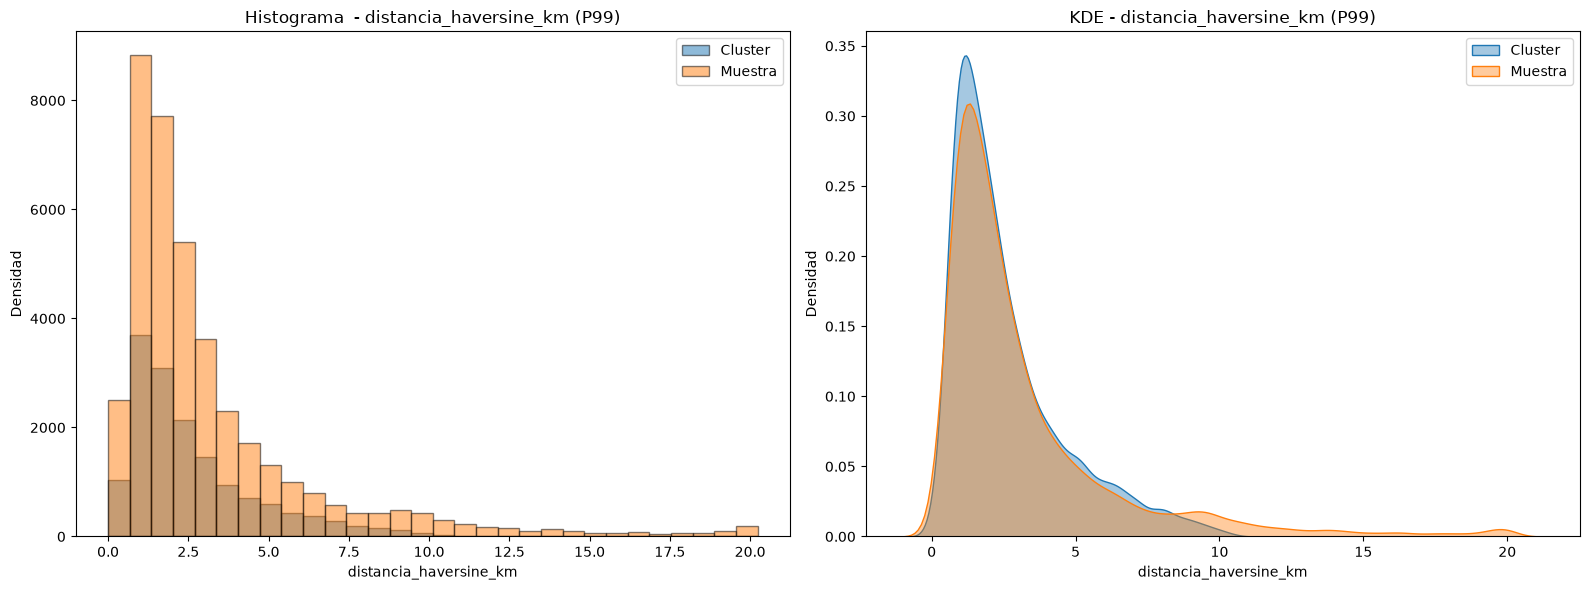

In [62]:
histograma_kde(df_km_c2,df,'distancia_haversine_km',30,99)

In [63]:
print("Min: ", df_km_c2['distancia_haversine_km'].min())
print("Max: ", df_km_c2['distancia_haversine_km'].max())

Min:  0.0006432125441629
Max:  10.6742031470224


In [64]:
df_km_c2[df_km_c2['distancia_haversine_km'] <0.05].shape

(24, 15)

In [65]:
df_km_c2[df_km_c2['distancia_haversine_km'] >12]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster


**Observaciones**
- Los viajes del cluster2 no poseen distancias extremadamente elevadas, aunque presentan algunas distancias muy cortas

#### **velocidad_promedio_kmh**

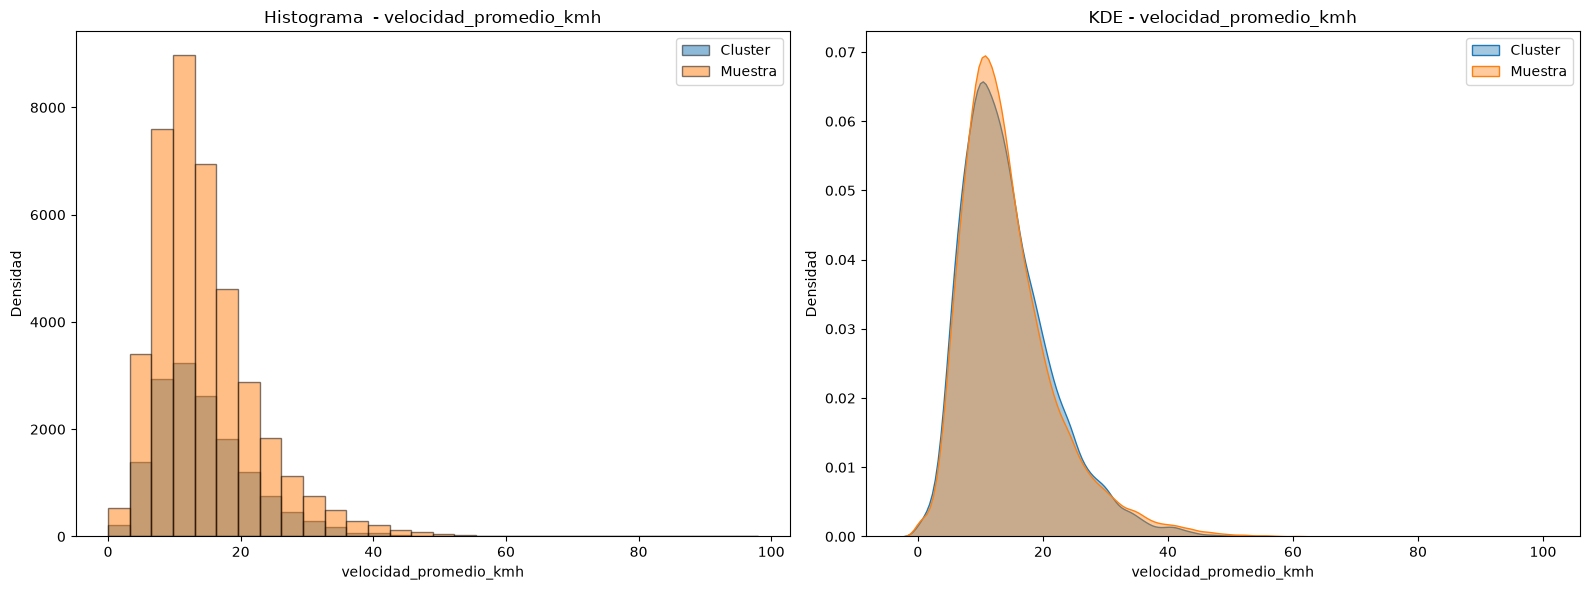

In [66]:
histograma_kde(df_km_c2,df,'velocidad_promedio_kmh')

In [67]:
df_km_c2[df_km_c2['velocidad_promedio_kmh'] > 60]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2573,1,1,N,1.366667,Wednesday,5,Wednesday,5,Externo,Externo,1.659864,72.872093,Madrugada,Madrugada,2
9795,1,1,N,2.800000,Sunday,4,Sunday,5,Manhattan,Brooklyn,2.803418,60.073250,Madrugada,Madrugada,2
14877,2,6,N,0.566667,Monday,5,Monday,5,Manhattan,Manhattan,0.788573,83.495913,Madrugada,Madrugada,2
36449,1,1,N,9.716667,Saturday,2,Saturday,2,Manhattan,Manhattan,10.356593,63.951517,Madrugada,Madrugada,2


**Observaciones**
- La distribución de velocidades promedio dentro del cluster presenta el mismo sesgo positivo que la muestra analizada. Asimismo, se encuentran ciertas velocidades extremas. 

#### **trip_duration**

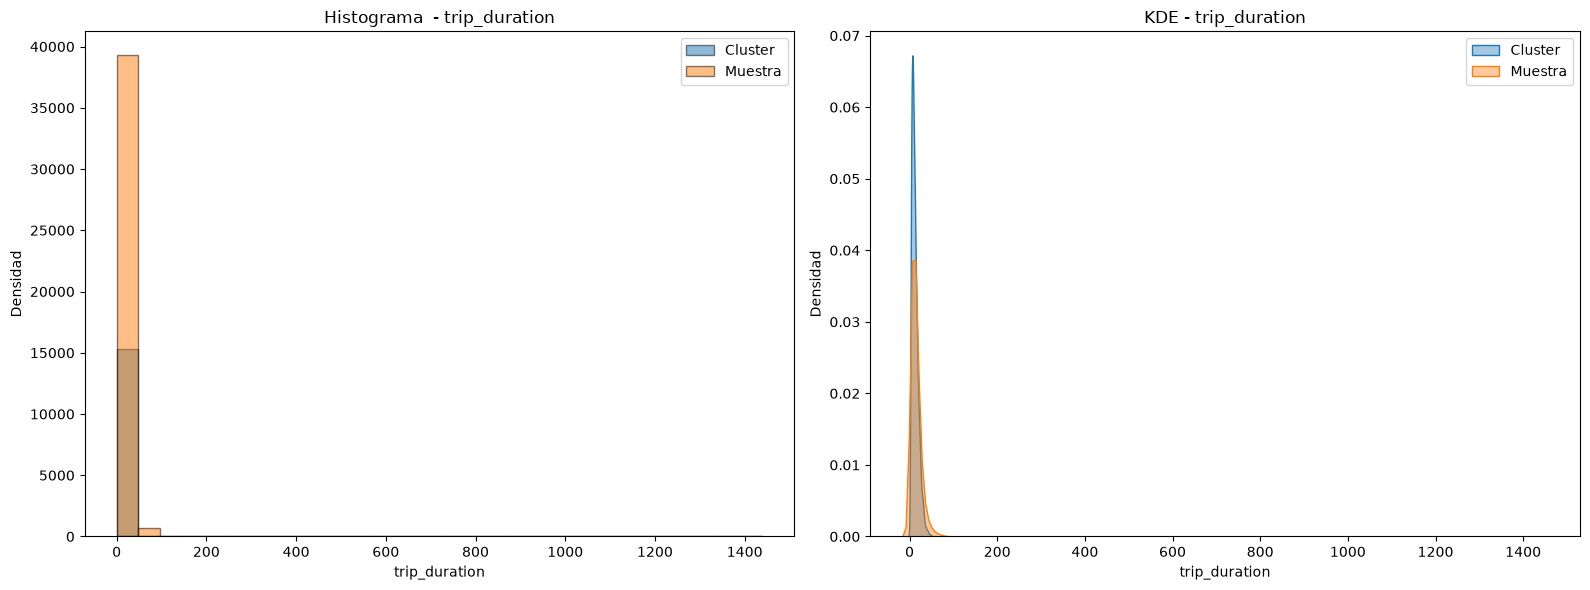

In [68]:
histograma_kde(df_km_c2,df,'trip_duration')

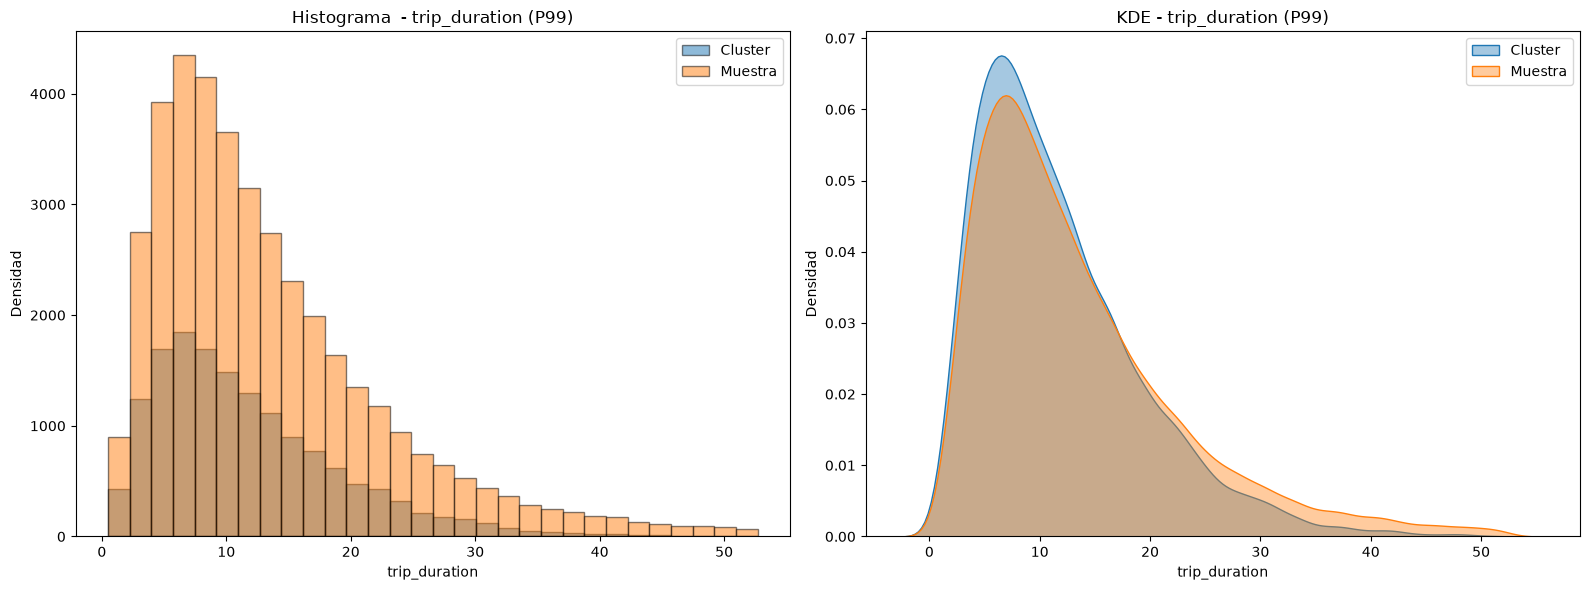

In [69]:
histograma_kde(df_km_c2,df,'trip_duration',30,99)

In [70]:
df_km_c2.shape

(15302, 15)

In [71]:
df_km_c2[df_km_c2['trip_duration'] < 60].shape

(15289, 15)

**Observaciones**
- El cluster 2 presenta un sesgo positivo tal como lo presenta la totalidad de la muestra analizada. Casi todos los viajes del cluster 2 duran menos de 1 hora.

### **2.5.4 Cluster 3**

#### **Filtración de Viajes dentro del Cluster**

In [72]:
df_km_c3 = df[df['k_mean_cluster'] == 3]
print("Tamaño Cluster: ", df_km_c3.shape[0])
print(f"Porcentaje del Total: {(df_km_c3.shape[0]/df.shape[0])*100:.2f}%")
df_km_c3.head()

Tamaño Cluster:  3189
Porcentaje del Total: 7.97%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
29,1,2,N,47.600000,Thursday,10,Thursday,11,Queens,Manhattan,9.386598,11.831846,Mañana,Mañana,3
33,2,1,N,16.083333,Friday,21,Friday,21,Queens,Manhattan,9.751168,36.377413,Noche,Noche,3
37,1,1,N,35.200000,Tuesday,20,Tuesday,20,Manhattan,Brooklyn,9.784537,16.678187,Noche,Noche,3
43,1,1,N,32.500000,Wednesday,12,Wednesday,12,Manhattan,Queens,11.087168,20.468617,Tarde,Tarde,3
52,2,6,N,21.100000,Friday,5,Friday,5,Manhattan,Queens,9.730580,27.669894,Madrugada,Madrugada,3


**Observaciones**
- El cluster 3 es relativamente pequeño. Los más grandes son el cluster 0 (53%) y 2 (40%).

#### **id_vendor**

In [73]:
df_km_c3['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.083614
1    0.075273
Name: count, dtype: float64

**Observaciones**
- El cluster 3 evidencia un 8.4% de los viajes que poseen el proveedor 2 y un 7.5% de los viajes del proveedor 1.

#### **dia_semana**

In [74]:
tabla_cont(df_km_c3,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,486,0,13,0,0,0,0
Monday,0,456,0,0,0,11,0
Saturday,0,0,344,8,0,0,0
Sunday,0,5,0,479,0,0,0
Thursday,11,0,0,0,448,0,0
Tuesday,0,0,0,0,0,464,11
Wednesday,0,0,0,0,18,0,435


In [75]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- El cluster 3 presenta una combinación de viajes que abarcaron un día y también dos días.

#### **borough**

In [76]:
tabla_cont(df_km_c3,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,0,0,0,3,2,0
Brooklyn,2,6,0,24,17,0
Externo,0,0,0,2,1,0
Manhattan,145,233,80,346,816,6
Queens,22,288,29,1044,120,3


In [77]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster 3 abarca una porción grande de los viajes que inician en Queens y terminan en un lugar distinto a este lugar. Además, evidencia la mayor cantidad de viajes que finalizaron en un lugar externo a los municipios analizados.

#### **store_and_fwd_flag**

In [78]:
df_km_c3['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.079084
Y    0.189655
Name: count, dtype: float64

In [79]:
df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    39768
Y      232
Name: count, dtype: int64

In [80]:
df_km_c3['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    3145
Y      44
Name: count, dtype: int64

**Observaciones**
- El cluster 3 evidencia una proporción pequeña del total de viajes no fueron almacenados localmente antes de ser enviados al servidor. No obstante, posee alrededor del 19% (44 registros) de los que si fueron almacenados localmente.

#### **franja_horaria**

In [81]:
tabla_cont(df_km_c3,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,353,40,0,0
Mañana,0,607,86,0
Tarde,3,0,911,176
Noche,74,0,0,939


In [82]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- Los viajes del cluster 3 suelen presentar en una pequeña parte la distribución de las franjas horarias de la muestra en general, aunque alcanza el 40% de los viajes que inician en la madrugada y terminan en la mañana.

#### **passenger_count**

In [83]:
df_km_c3['passenger_count'].value_counts()

passenger_count
1    2173
2     518
5     187
3     135
6     103
4      73
Name: count, dtype: int64

In [84]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El número de pasajeros no es un aspecto que diferencie al cluster, se observa que conserva el mismo orden de magnitud en la variable.

#### **distancia_haversine_km**

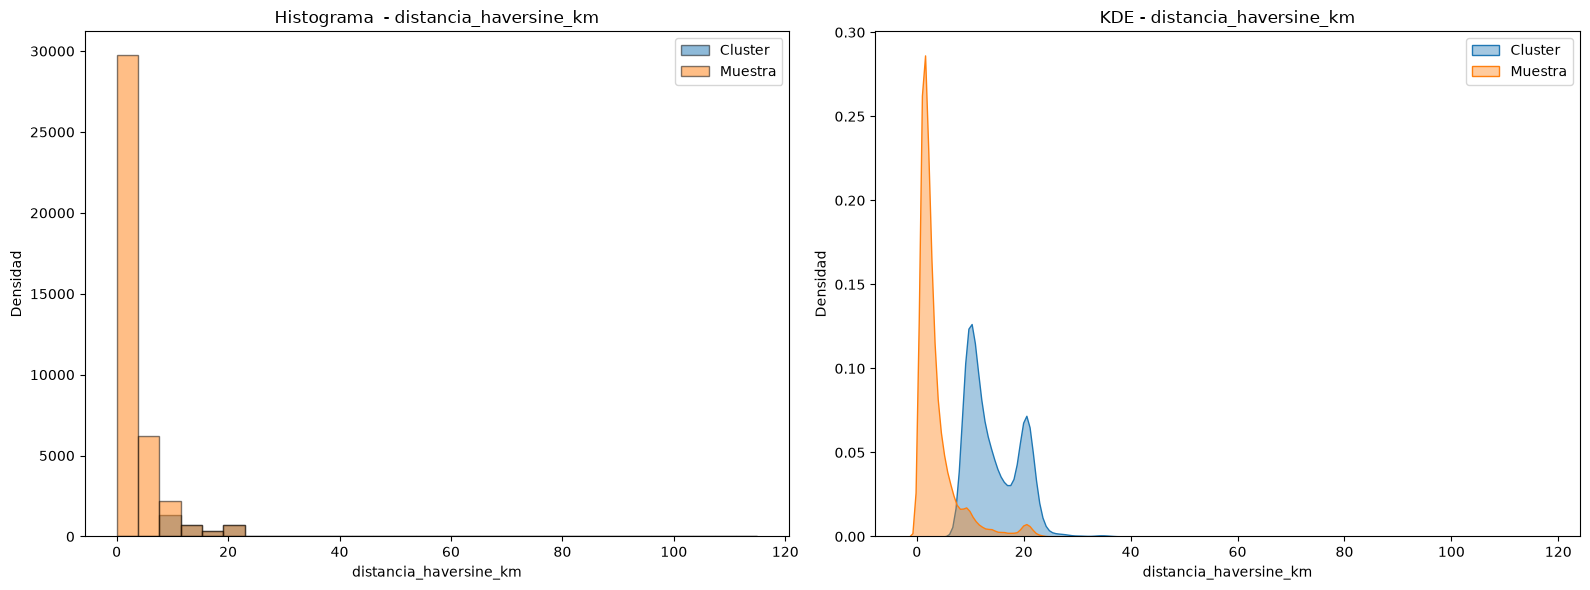

In [85]:
histograma_kde(df_km_c3,df,'distancia_haversine_km')

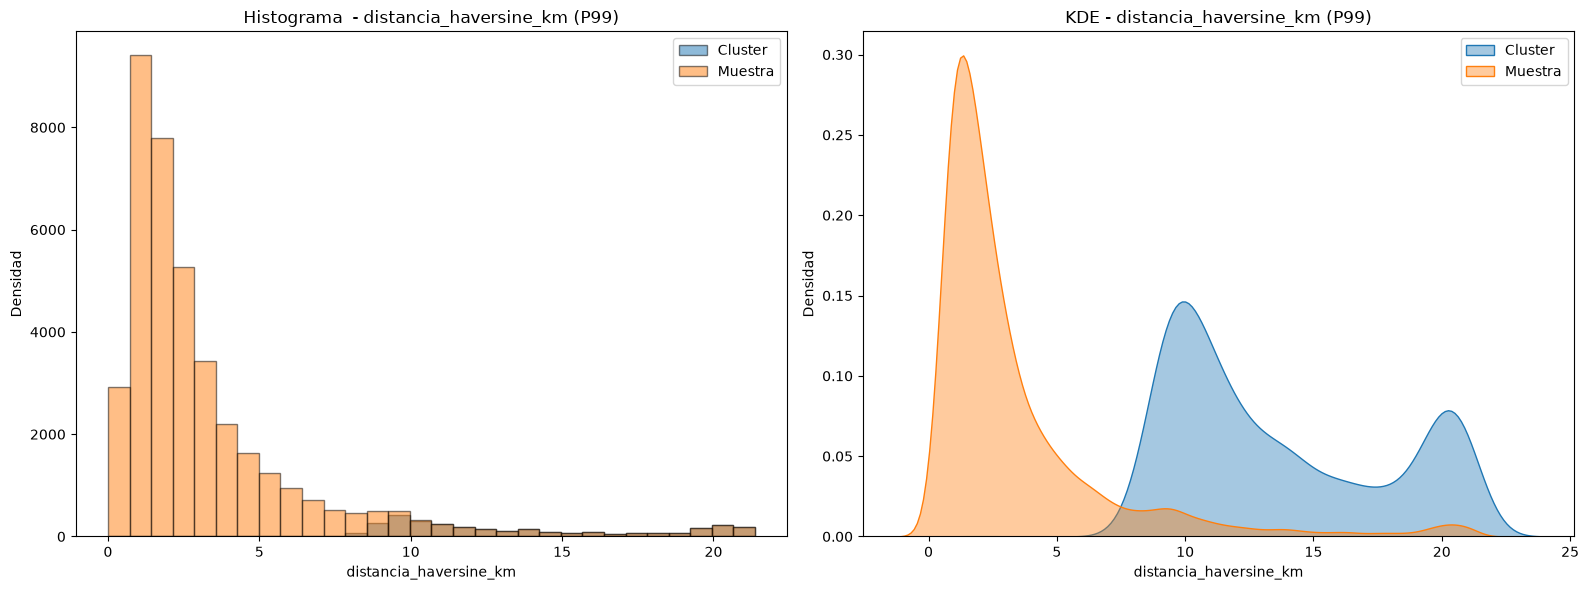

In [86]:
histograma_kde(df_km_c3,df,'distancia_haversine_km',30,99)

**Observaciones**
- Los viajes del cluster 3 selen poseer distancias mayores a los de la distribución de la muestra en general.

#### **velocidad_promedio_kmh**

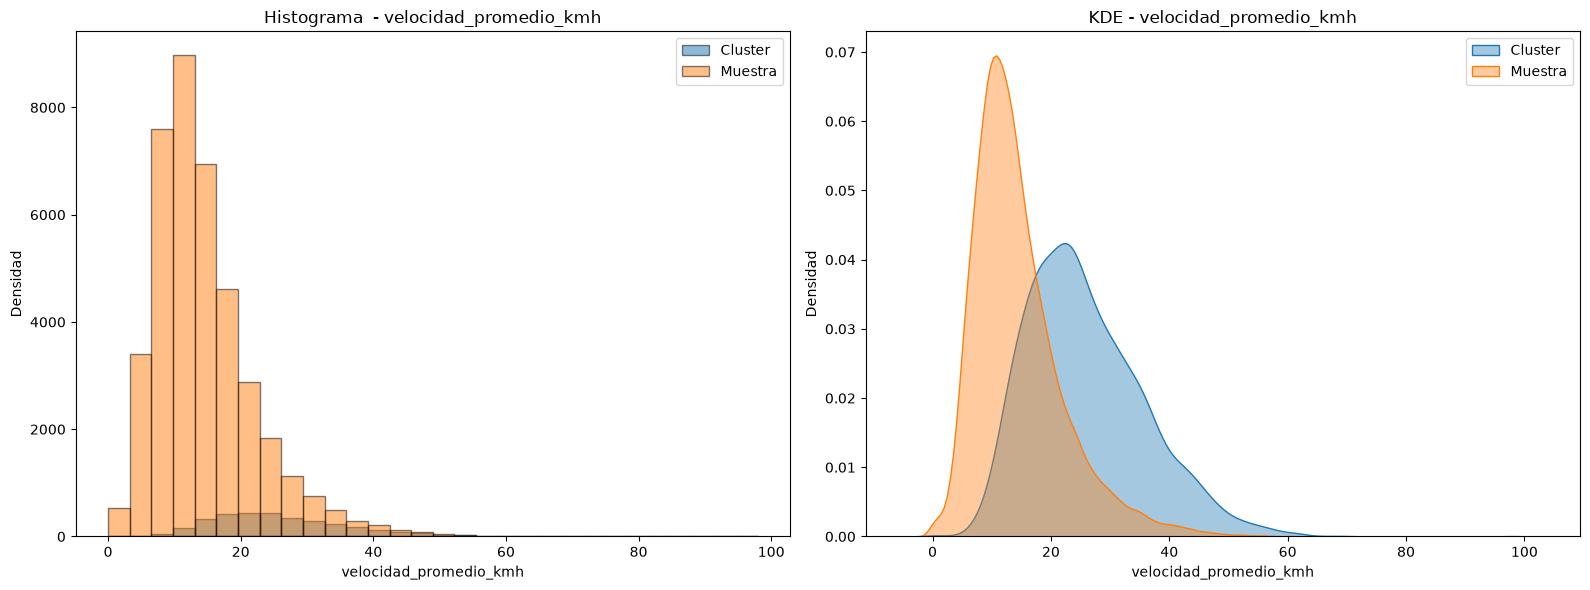

In [87]:
histograma_kde(df_km_c3,df,'velocidad_promedio_kmh')

**Observaciones**
- La mayor concentración de velocidades del cluster tienen un valor superior a los 20km/h.

#### **trip_duration**

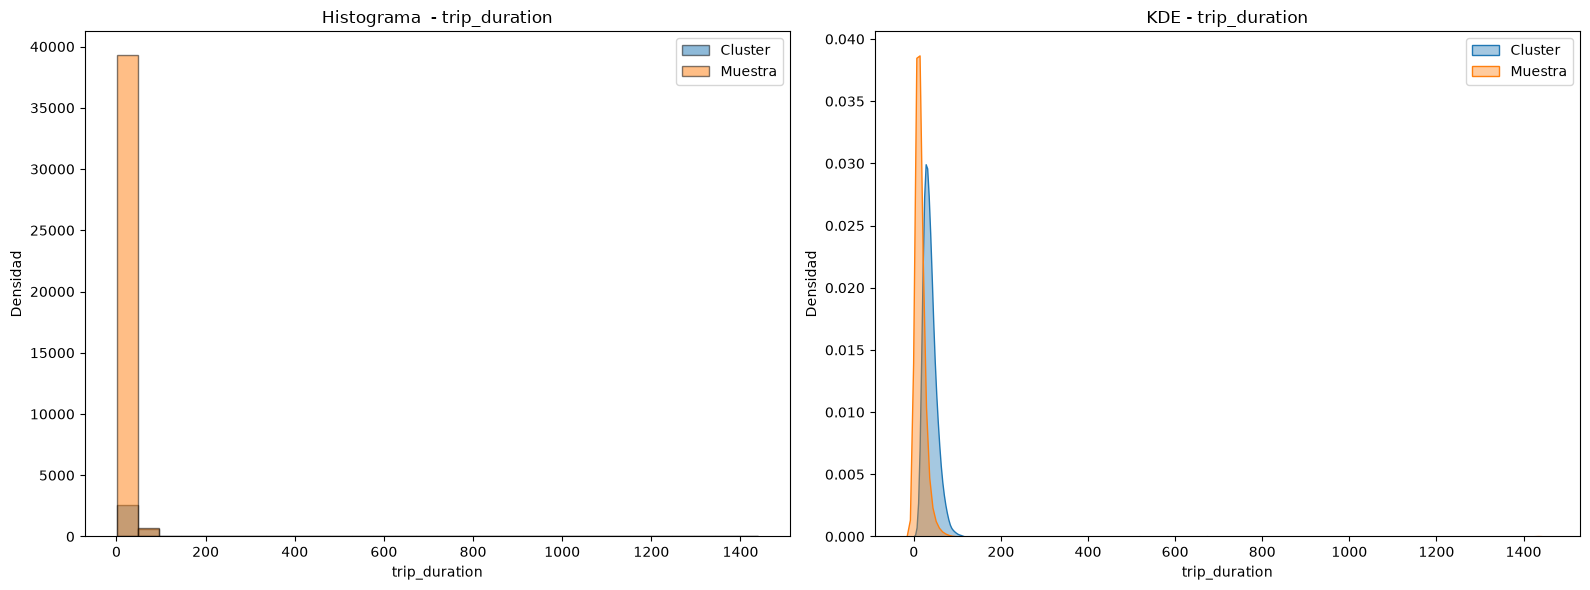

In [88]:
histograma_kde(df_km_c3,df,'trip_duration')

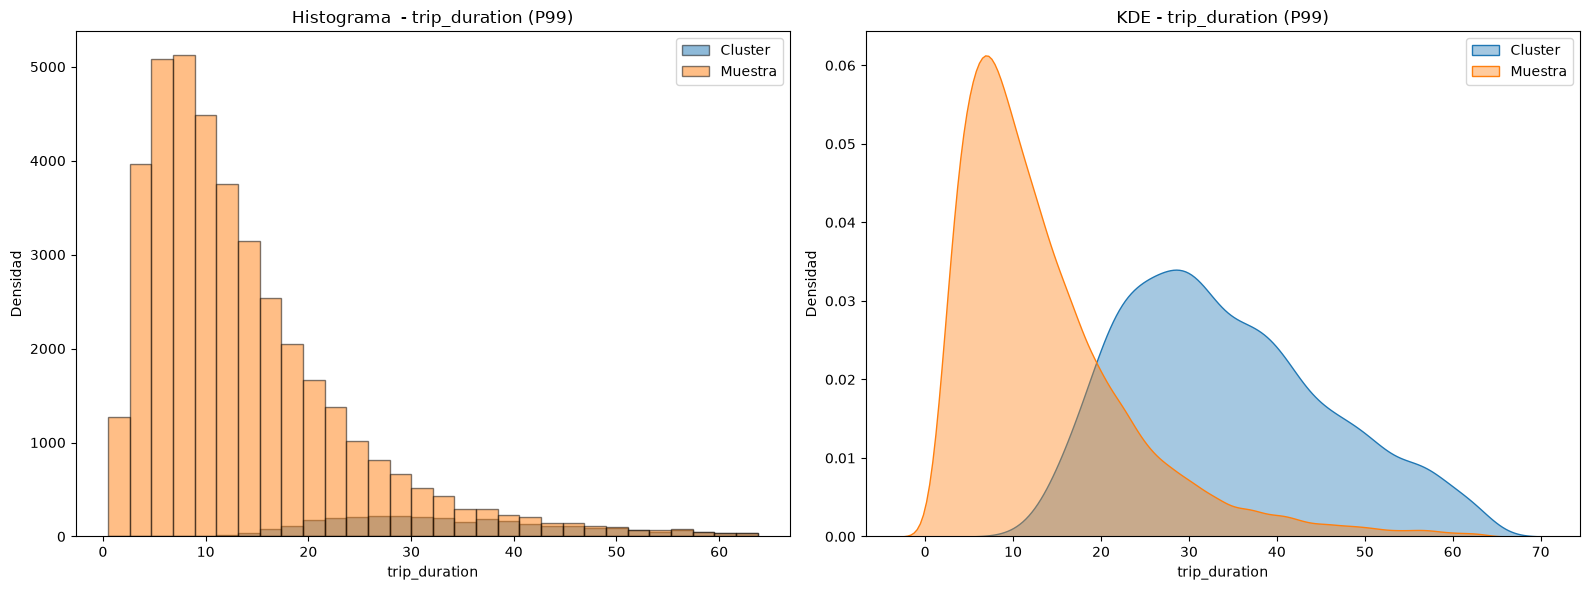

In [89]:
histograma_kde(df_km_c3,df,'trip_duration',30,99)

**Observaciones**
- La concentración de viajes con alta duración es mayor en los viajes del cluster 3 en contraste con los de la muestra en general.

# **3. DBSCAN**

## **3.1 Búsqueda Hiperparámetros**

In [90]:
output_dir = "../output/role_2"
output_file = os.path.join(output_dir, "dbscan_min_samples.csv")
log_file = os.path.join(output_dir, "debug.log")

os.makedirs(output_dir, exist_ok=True)


def log(mensaje):
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(mensaje + "\n")
        f.flush()


if os.path.exists(output_file):

    resultados_dbscan = pd.read_csv(output_file)

    log(f"El archivo ya existe. Resultados cargados desde: {output_file}")

else:

    # Limpiar log anterior
    with open(log_file, "w", encoding="utf-8") as f:
        f.write("INICIO DE EJECUCIÓN DBSCAN\n")
        f.write("=" * 60 + "\n")

    # eps fijo
    eps = 1.0

    # Valores de min_samples a evaluar
    min_samples_values = [5, 10, 15, 20, 25, 30]

    resultados_dbscan = []

    for min_samples in min_samples_values:

        log("")
        log("=" * 60)
        log(f"Probando DBSCAN: eps={eps}, min_samples={min_samples}")
        log("=" * 60)

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        # ---------------------------------
        # DBSCAN
        # ---------------------------------

        log("→ Ejecutando DBSCAN...")

        labels = dbscan.fit_predict(X_scaled)

        log("✓ DBSCAN terminado")

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        porcentaje_ruido = (
            labels == -1
        ).mean() * 100

        log(f"→ Número de clusters: {n_clusters}")
        log(f"→ Porcentaje de ruido: {porcentaje_ruido:.2f}%")

        if n_clusters >= 2:

            mask = labels != -1

            X_eval = X_scaled[mask]
            labels_eval = labels[mask]

            log(
                f"→ Observaciones para evaluación: "
                f"{len(X_eval)}"
            )

            # ---------------------------------
            # SILHOUETTE
            # ---------------------------------

            log("→ Calculando Silhouette...")

            silhouette = silhouette_score(
                X_eval,
                labels_eval
            )

            log(
                f"✓ Silhouette terminado: "
                f"{silhouette:.4f}"
            )

            # ---------------------------------
            # DAVIES-BOULDIN
            # ---------------------------------

            log("→ Calculando Davies-Bouldin...")

            davies_bouldin = davies_bouldin_score(
                X_eval,
                labels_eval
            )

            log(
                f"✓ Davies-Bouldin terminado: "
                f"{davies_bouldin:.4f}"
            )

            # ---------------------------------
            # CALINSKI-HARABASZ
            # ---------------------------------

            log("→ Calculando Calinski-Harabasz...")

            calinski_harabasz = calinski_harabasz_score(
                X_eval,
                labels_eval
            )

            log(
                f"✓ Calinski-Harabasz terminado: "
                f"{calinski_harabasz:.4f}"
            )

        else:

            log(
                "→ Menos de 2 clusters. "
                "Métricas no calculadas."
            )

            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "ruido_%": porcentaje_ruido,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz
        })

        log(
            f"✓ min_samples={min_samples} "
            "procesado correctamente"
        )

    resultados_dbscan = pd.DataFrame(resultados_dbscan)

    resultados_dbscan.to_csv(
        output_file,
        index=False
    )

    log("")
    log("=" * 60)
    log("✓ TODOS LOS RESULTADOS CALCULADOS")
    log(f"Archivo: {output_file}")
    log("=" * 60)

## **3.2 Visualización Métricas**

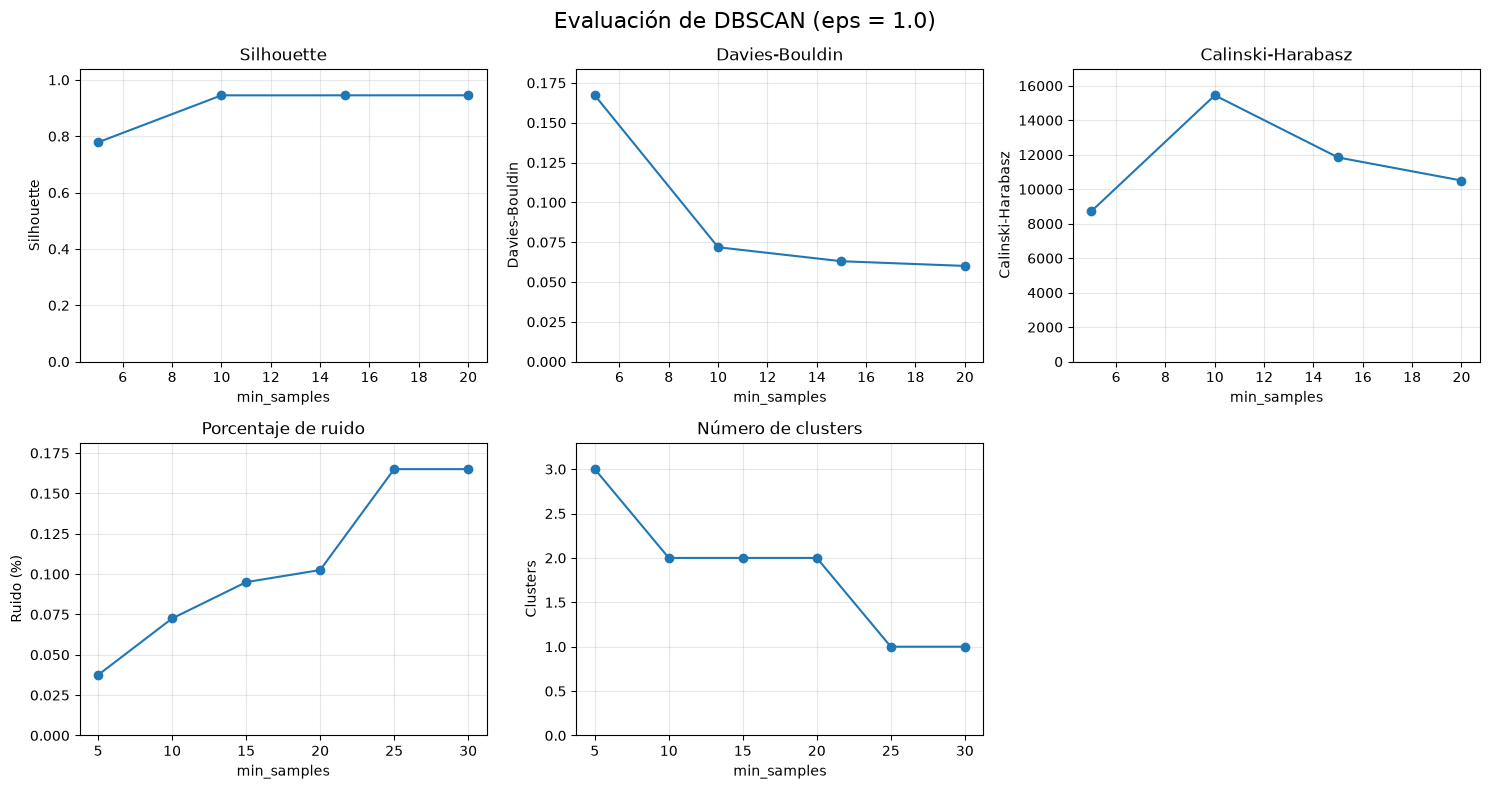

In [91]:
resultados_dbscan = resultados_dbscan.sort_values("min_samples")

graficos = [
    ("silhouette", "Silhouette", "Silhouette"),
    ("davies_bouldin", "Davies-Bouldin", "Davies-Bouldin"),
    ("calinski_harabasz", "Calinski-Harabasz", "Calinski-Harabasz"),
    ("ruido_%", "Ruido (%)", "Porcentaje de ruido"),
    ("n_clusters", "Clusters", "Número de clusters")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, (columna, ylabel, titulo) in zip(axes, graficos):

    ax.plot(
        resultados_dbscan["min_samples"],
        resultados_dbscan[columna],
        marker="o"
    )

    ax.set_title(titulo)
    ax.set_xlabel("min_samples")
    ax.set_ylabel(ylabel)

    # Eje Y empieza en 0 y deja margen superior
    ax.set_ylim(
        0,
        resultados_dbscan[columna].max() * 1.1
    )

    ax.grid(True, alpha=0.3)

axes[-1].axis("off")

fig.suptitle(
    "Evaluación de DBSCAN (eps = 1.0)",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Observaciones**
- El índice de Silhouette expresa valores superiores a 0.9 para tamaños de muestra mínimos mayores o iguales a 10 observaciones, lo que indica una buena separación entre clusteres.
- El análisis del índice de Davies-Bouldin expone que los tamaños de muestra 10, 15 y 20 poseen un mejor contraste entre separación y compactación de los clusteres que los tamaños 5, 25 y 30 (estos dos últimos no poseen índice porque la configuración indico solamente un cluster).
- La observación del índice de Calinski Harabasz para distintos tamaños mínimos de muestra expone que la configuración con n=15 observaciones posee la mejor relación entre cohesión y compactación en contraste a los otros tamaños de muestra analizados.
- El porcentaje de ruido tiende a aumentar a medida que se aumenta el tamaño mínimo de la muestra.
- Se evidencia que los tamaños de muestra mínimos 25 y 30 generan únicamente un cluster, lo que no es ideal, debido a que se procura segmentar la información para identificar patrones en la data.
- Se escoge el tamapo de muestra mínimo min_samples = 10, debido a que presenta un mejor equilibrio entre las métricas expuestas, logrando uno de los mejores índicas de silueta y Davies-Boulding,  y alcanzando el mejor índice de Calinski-Harabasz para los tamaños analizados. Asimismo, logra disminuir el porcentaje en mayor proporción en contraste a tamaños superiores.

## **3.3 Simulación con min_samples=10**

In [92]:
output_dir = "../output/role_2"

output_file = os.path.join(
    output_dir,
    "dbscan_eps_results_min_s10.csv"
)

log_file = os.path.join(
    output_dir,
    "debug_eps_min_s10.log"
)

eps_values = np.round(
    np.arange(0.3, 1.4, 0.1),
    1
)

min_samples = 10

os.makedirs(output_dir, exist_ok=True)


def log(mensaje):
    with open(log_file, "a", encoding="utf-8") as f:
        f.write(mensaje + "\n")
        f.flush()


if os.path.exists(output_file):

    resultados_dbscan_eps = pd.read_csv(output_file)

    resultados_dbscan_eps["eps"] = (
        resultados_dbscan_eps["eps"].round(1)
    )

    resultados_dbscan_eps = (
        resultados_dbscan_eps
        .drop_duplicates(
            subset="eps",
            keep="last"
        )
        .sort_values("eps")
        .reset_index(drop=True)
    )

    resultados_dbscan_eps.to_csv(
        output_file,
        index=False
    )

    log(
        f"Resultados existentes cargados: "
        f"{len(resultados_dbscan_eps)}"
    )

else:

    resultados_dbscan_eps = pd.DataFrame(
        columns=[
            "eps",
            "min_samples",
            "n_clusters",
            "ruido_%",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz"
        ]
    )

    resultados_dbscan_eps.to_csv(
        output_file,
        index=False
    )

    log("No existían resultados previos.")


for eps in eps_values:

    eps = round(float(eps), 1)

    if eps in resultados_dbscan_eps["eps"].values:
        log(f"eps={eps:.1f} ya existe. Se omite.")
        continue

    log("")
    log(f"Procesando eps={eps:.1f}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(X_scaled)

    log("DBSCAN terminado.")

    n_clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    porcentaje_ruido = (
        labels == -1
    ).mean() * 100

    log(f"Clusters: {n_clusters}")
    log(f"Ruido: {porcentaje_ruido:.2f}%")

    if n_clusters >= 2:

        mask = labels != -1

        X_eval = X_scaled[mask]
        labels_eval = labels[mask]

        log("Calculando métricas...")

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies_bouldin = davies_bouldin_score(
            X_eval,
            labels_eval
        )

        calinski_harabasz = calinski_harabasz_score(
            X_eval,
            labels_eval
        )

        log(f"Silhouette: {silhouette:.4f}")
        log(f"Davies-Bouldin: {davies_bouldin:.4f}")
        log(
            f"Calinski-Harabasz: "
            f"{calinski_harabasz:.4f}"
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

        log(
            "Menos de 2 clusters. "
            "Métricas no calculadas."
        )

    nuevo_resultado = pd.DataFrame([{
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "ruido_%": porcentaje_ruido,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz
    }])

    resultados_dbscan_eps = pd.concat(
        [
            resultados_dbscan_eps,
            nuevo_resultado
        ],
        ignore_index=True
    )

    resultados_dbscan_eps["eps"] = (
        resultados_dbscan_eps["eps"].round(1)
    )

    resultados_dbscan_eps = (
        resultados_dbscan_eps
        .drop_duplicates(
            subset="eps",
            keep="last"
        )
        .sort_values("eps")
        .reset_index(drop=True)
    )

    resultados_dbscan_eps.to_csv(
        output_file,
        index=False
    )

    log(
        f"eps={eps:.1f} guardado correctamente."
    )


log("")
log("Experimento terminado.")
log(
    f"Total de resultados: "
    f"{len(resultados_dbscan_eps)}"
)

In [93]:
resultados_dbscan_eps

,eps,min_samples,n_clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz
0,0.3,10,1,0.4975,NaN,NaN,NaN
1,0.4,10,1,0.3025,NaN,NaN,NaN
2,0.5,10,2,0.2075,0.945531,0.050365,5075.195580
3,0.6,10,2,0.1625,0.945439,0.054608,8271.245176
4,0.7,10,2,0.1150,0.945319,0.058264,10047.144393
5,0.8,10,2,0.1075,0.945311,0.059548,10497.117513
6,0.9,10,2,0.1050,0.945303,0.059554,10492.037891
7,1.0,10,2,0.0725,0.945207,0.071818,15445.763008
8,1.1,10,2,0.0625,0.945176,0.071838,15414.482012
9,1.2,10,2,0.0550,0.945159,0.076254,16759.175128


## **3.3 Visualización Métricas min_samples=10**

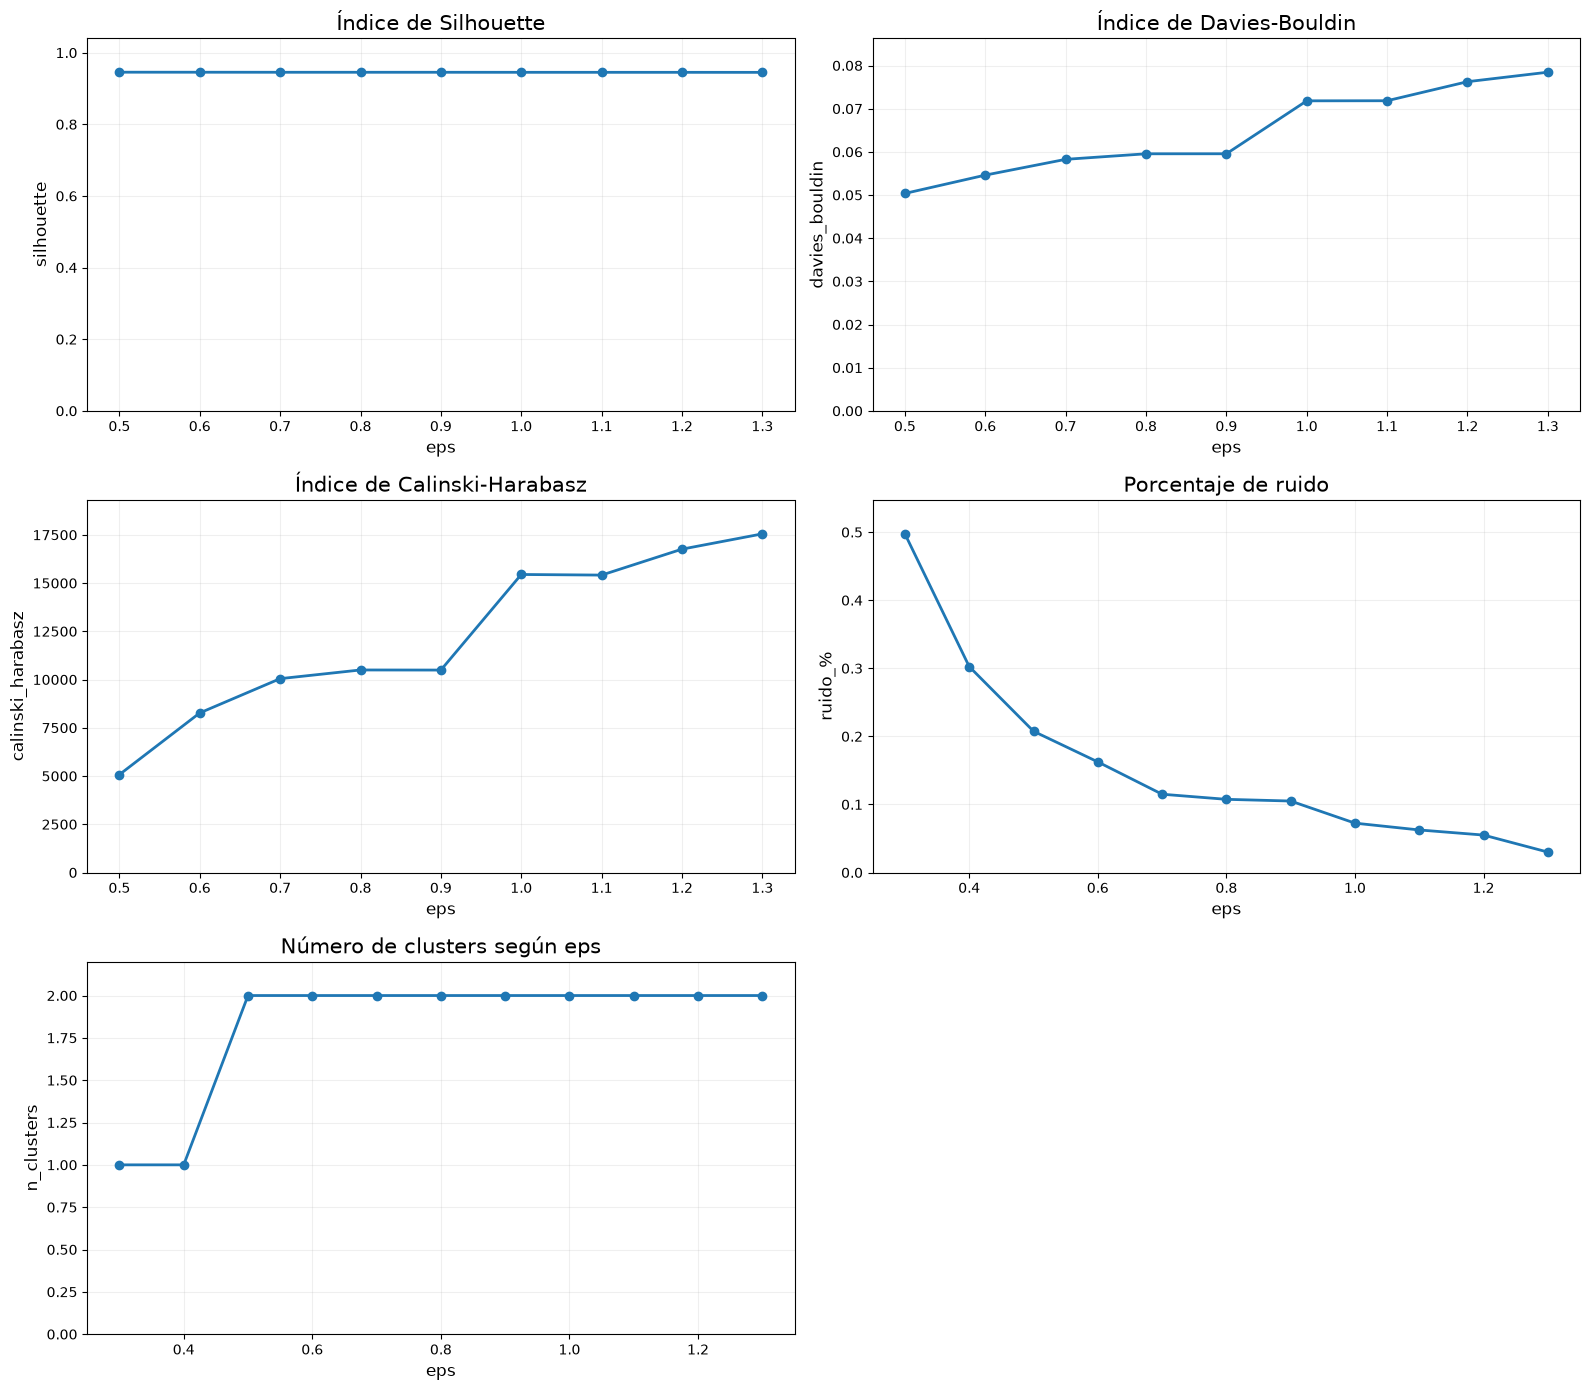

In [94]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

metricas = [
    ("silhouette", "Índice de Silhouette"),
    ("davies_bouldin", "Índice de Davies-Bouldin"),
    ("calinski_harabasz", "Índice de Calinski-Harabasz"),
    ("ruido_%", "Porcentaje de ruido"),
    ("n_clusters", "Número de clusters según eps")
]

# Ordenar resultados por eps
datos = resultados_dbscan_eps.sort_values("eps")

for ax, (metrica, titulo) in zip(axes.flat, metricas):

    valores = datos[metrica].dropna()

    ax.plot(
        datos["eps"],
        datos[metrica],
        marker="o",
        linewidth=2
    )

    ax.set_title(titulo, fontsize=15)
    ax.set_xlabel("eps", fontsize=12)
    ax.set_ylabel(metrica, fontsize=12)

    # Eje Y comienza en 0 y se adapta automáticamente
    max_valor = valores.max()

    if max_valor > 0:
        ax.set_ylim(
            bottom=0,
            top=max_valor * 1.10
        )

    ax.grid(alpha=0.2)

# Ocultar el sexto espacio
axes[2, 1].axis("off")

plt.tight_layout()

plt.show()

**Observaciones**
- Se considera un epsilon de 0.9 razonable en el ejercicio, debido a que posee un índice de silueta de 0.8 que expresa una buena separación de los clusteres. De igual manera, presenta un buen equilibrio entre los índices de Davies-Bouldin y Calinski-Harabasz. 

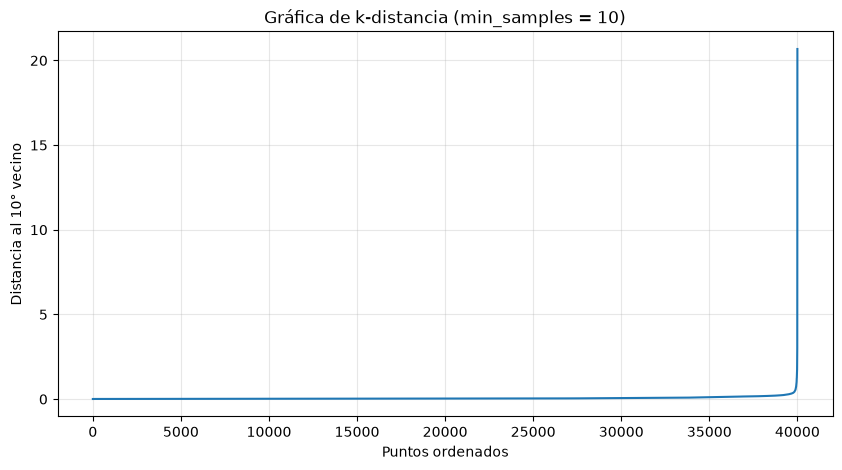

In [95]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X)

distances, indices = neighbors.kneighbors(X)

# Distancia al k-ésimo vecino
k_distances = distances[:, -1]

# Ordenar las distancias
k_distances = np.sort(k_distances)

# =========================
# Gráfica k-distancia
# =========================
plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}° vecino")
plt.title(f"Gráfica de k-distancia (min_samples = {min_samples})")

plt.grid(True, alpha=0.3)
plt.show()

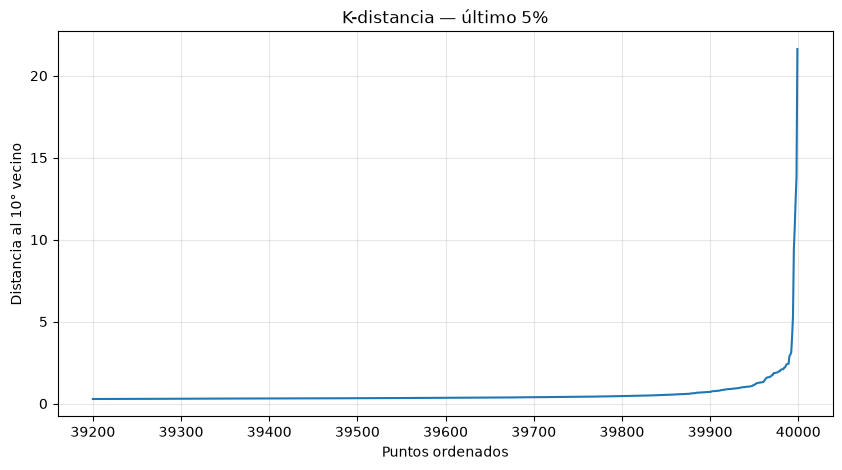

In [151]:
n = len(k_distances)

inicio = int(n * 0.98)

plt.figure(figsize=(10, 5))
plt.plot(
    range(inicio, n),
    k_distances[inicio:]
)

plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al 10° vecino")
plt.title("K-distancia — último 5%")
plt.grid(True, alpha=0.3)

plt.show()

**Observaciones**
- Existen menos de 50 observaciones que poseen una distancia extremadamente grande al décimo vecino más cercano, estos registros pueden ser catalogados como ruido por el DBSCAN

## **3.4 Análisis de Clusteres con $\epsilon=0.9$ y min_samples=10**

### **3.4.0 Implementación DBSCAN**

In [96]:
dbscan = DBSCAN(
    eps=0.9,
    min_samples=10
)

labels = dbscan.fit_predict(X_scaled)

df['k_cluster_dbscan'] = labels

In [97]:
df['k_cluster_dbscan'].value_counts()

k_cluster_dbscan
 0    39935
-1       42
 1       23
Name: count, dtype: int64

### **3.4.1 Cluster 0**

#### **Filtración Viajes Cluster 0**

In [98]:
df_dbs_c0 = df[df['k_cluster_dbscan'] == 0]
print("Tamaño Cluster: ", df_dbs_c0.shape[0])
print(f"Porcentaje del Total: {(df_dbs_c0.shape[0]/df.shape[0])*100:.2f}%")
df_dbs_c0.head()

Tamaño Cluster:  39935
Porcentaje del Total: 99.84%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan
0,1,1,N,5.550000,Saturday,18,Saturday,18,Manhattan,Manhattan,1.199834,12.971179,Noche,Noche,0,0
1,2,1,N,23.333333,Wednesday,18,Wednesday,18,Manhattan,Manhattan,4.459326,11.466837,Noche,Noche,0,0
2,1,1,N,5.200000,Saturday,10,Saturday,10,Manhattan,Manhattan,1.499389,17.300644,Mañana,Mañana,2,0
3,2,6,N,4.966667,Thursday,22,Thursday,22,Manhattan,Manhattan,0.909572,10.988118,Noche,Noche,0,0
4,1,1,N,12.983333,Friday,8,Friday,9,Manhattan,Manhattan,1.240744,5.733860,Mañana,Mañana,2,0


**Observaciones**
- El cluster 0 abarca casi el 99% de todas los registros.

#### **vendor_id**

In [99]:
df_dbs_c0['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.997330
1    0.999571
Name: count, dtype: float64

**Observaciones**
- El cluster 0 abarca aproximadamente el 99% de todos los viajes del proveedor 2 y el 99% de los viajes del proveedor 1 en la muestra analizada.

#### **dia_semana**

In [100]:
tabla_cont(df_dbs_c0,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6030,0,89,0,0,0,0
Monday,0,5217,0,0,0,39,0
Saturday,0,0,6005,75,0,0,0
Sunday,0,26,0,5347,0,0,0
Thursday,65,0,0,0,5816,0,0
Tuesday,0,0,0,0,0,5469,39
Wednesday,0,0,0,0,58,0,5660


In [101]:
tabla_cont(df, 'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **borough**

In [102]:
tabla_cont(df_dbs_c0,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,18,0,0,16,2,0
Brooklyn,2,447,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,228,1330,103,33766,1446,6
Queens,32,332,28,1329,569,2


In [103]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **store_and_fwd_flag**

In [104]:
df_dbs_c0['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.998366
Y    1.000000
Name: count, dtype: float64

**Observaciones**
- El cluster posee todas los viajes que fueron registrados localmente previos a ser envidados al servidor y el 99.7% de los que no se registraron localmente previo al envío

#### **franja_horaria**

In [105]:
tabla_cont(df_dbs_c0,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4665,100,0,0
Mañana,0,9368,484,0
Tarde,0,0,11071,584
Noche,391,0,0,13272


In [106]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **passenger_count**

In [107]:
df_dbs_c0['passenger_count'].value_counts()

passenger_count
1    28352
2     5724
5     2165
3     1670
6     1254
4      770
Name: count, dtype: int64

In [108]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **distancia_haversine_km**

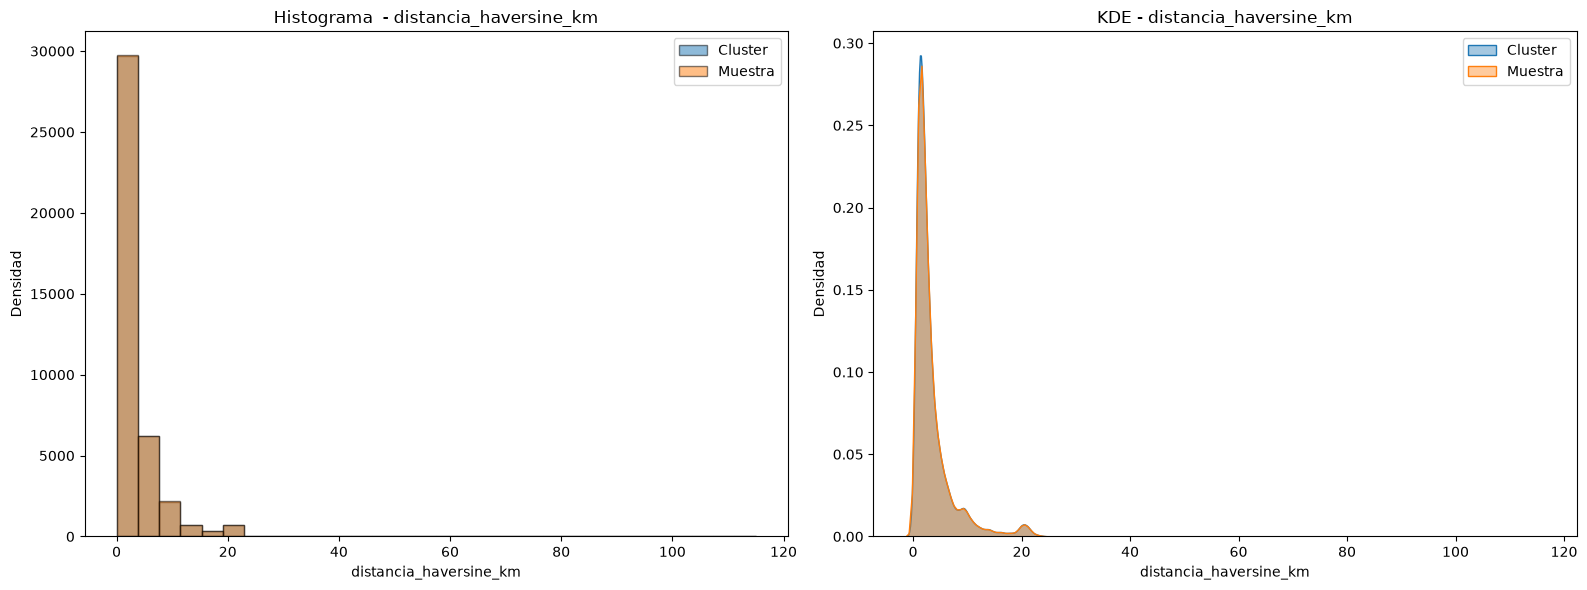

In [109]:
histograma_kde(df_dbs_c0,df,'distancia_haversine_km')

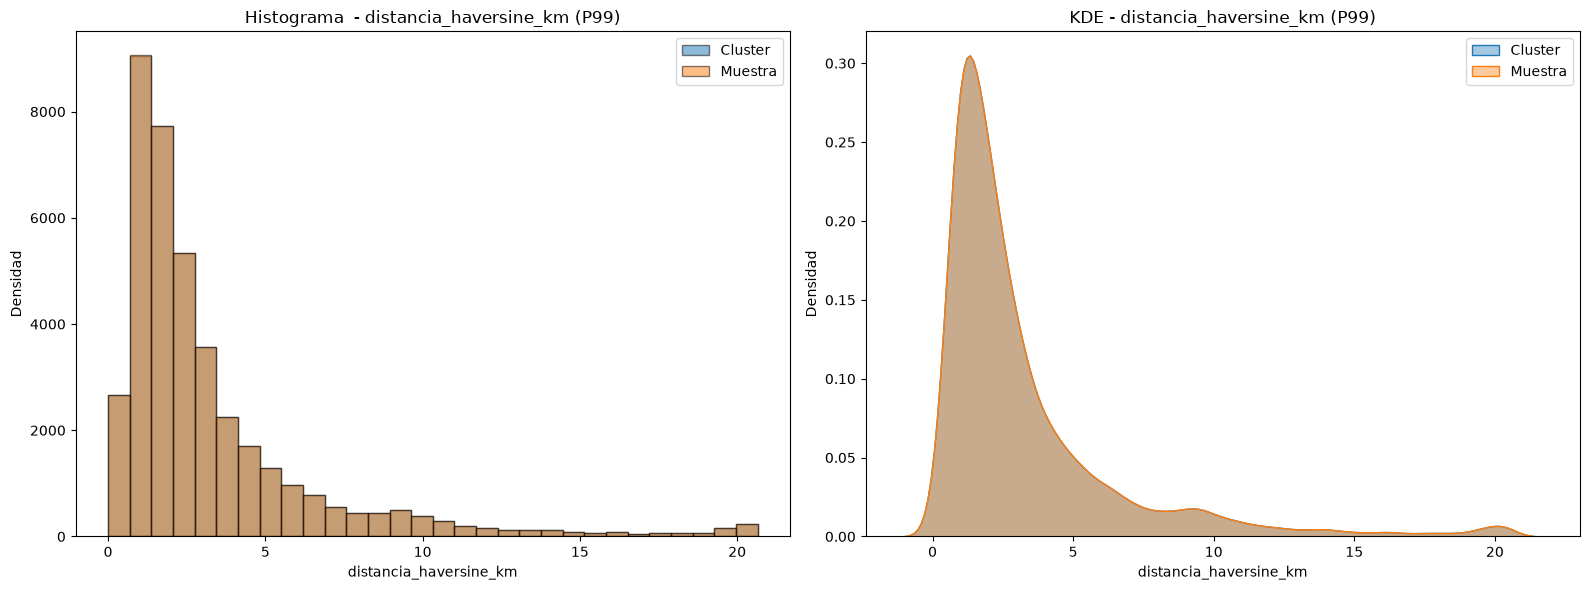

In [110]:
histograma_kde(df_dbs_c0,df,'distancia_haversine_km',30,99)

**Observaciones**
- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **velocidad_promedio_kmh**

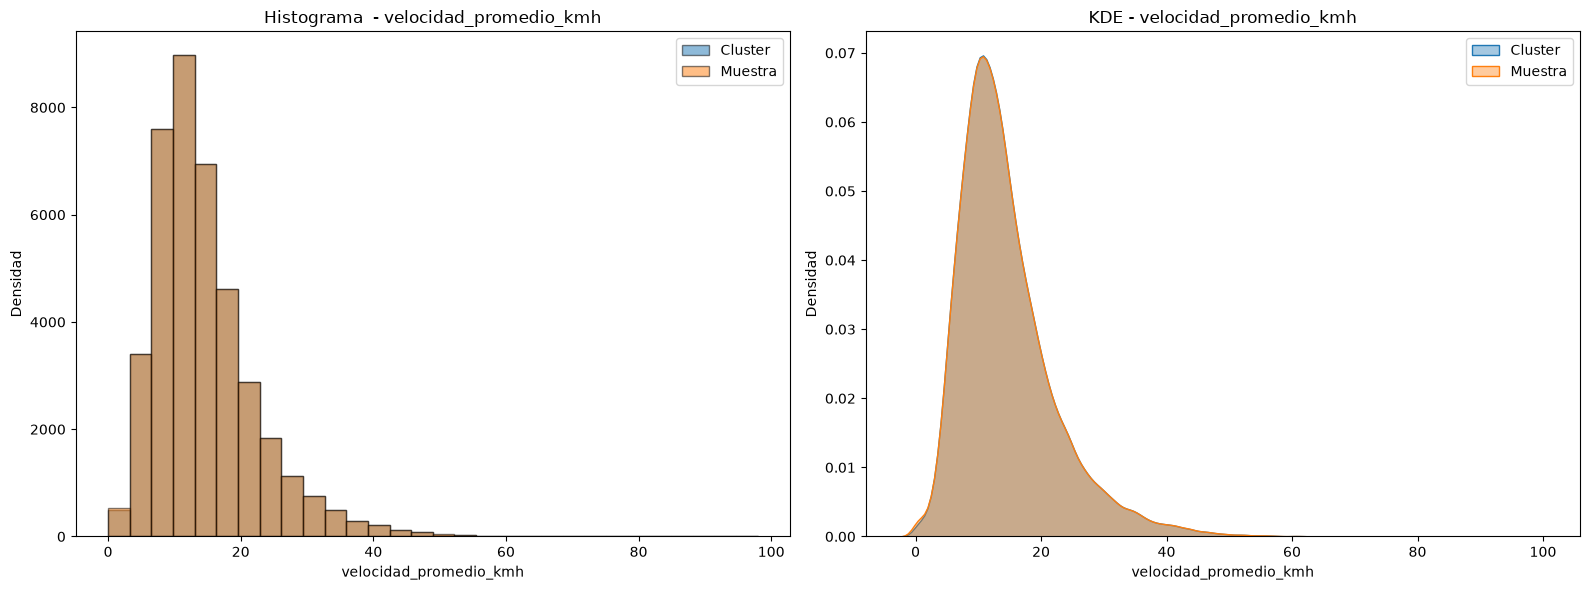

In [111]:
histograma_kde(df_dbs_c0,df,'velocidad_promedio_kmh')

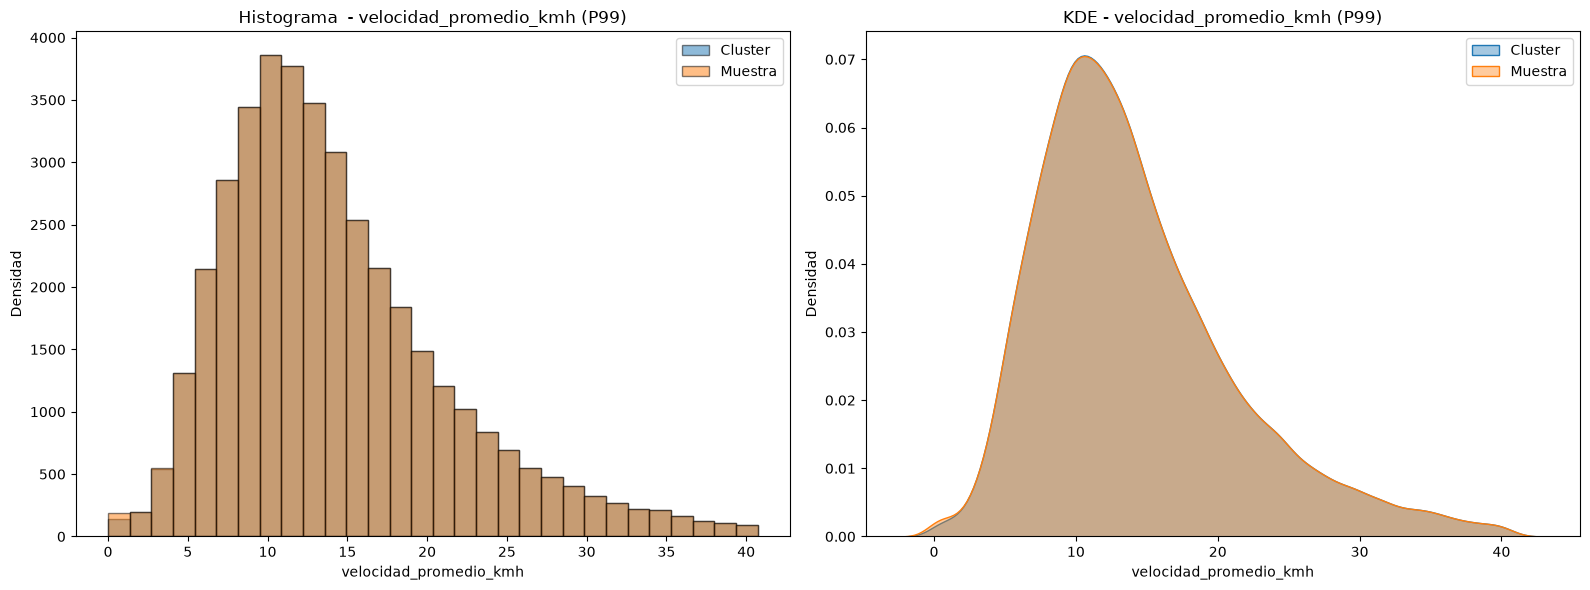

In [112]:
histograma_kde(df_dbs_c0,df,'velocidad_promedio_kmh',30,99)

In [113]:
df_dbs_c0[df_dbs_c0['velocidad_promedio_kmh'] > 60]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan
361,2,5,N,15.716667,Friday,5,Friday,5,Queens,Queens,16.310159,62.265717,Madrugada,Madrugada,3,0
2573,1,1,N,1.366667,Wednesday,5,Wednesday,5,Externo,Externo,1.659864,72.872093,Madrugada,Madrugada,2,0
4500,1,1,N,12.433333,Tuesday,19,Tuesday,20,Manhattan,Bronx,12.591765,60.764550,Noche,Noche,3,0
9795,1,1,N,2.800000,Sunday,4,Sunday,5,Manhattan,Brooklyn,2.803418,60.073250,Madrugada,Madrugada,2,0
9966,2,1,N,10.533333,Saturday,16,Saturday,16,Externo,Manhattan,17.193355,97.936832,Tarde,Tarde,3,0
10796,1,1,N,15.666667,Wednesday,20,Wednesday,20,Manhattan,Bronx,16.213613,62.094687,Noche,Noche,3,0
12000,1,1,N,15.216667,Thursday,5,Thursday,6,Manhattan,Externo,15.376707,60.631048,Madrugada,Mañana,3,0
12049,1,1,N,16.250000,Saturday,2,Saturday,3,Queens,Queens,18.079652,66.755638,Madrugada,Madrugada,3,0
14877,2,6,N,0.566667,Monday,5,Monday,5,Manhattan,Manhattan,0.788573,83.495913,Madrugada,Madrugada,2,0
24483,2,2,N,19.200000,Monday,3,Monday,3,Brooklyn,Queens,19.352845,60.477639,Madrugada,Madrugada,3,0


**Observaciones**
- No se evidencia un patron diferenciador al analizar la clusterización con esta variable.

#### **trip_duration**

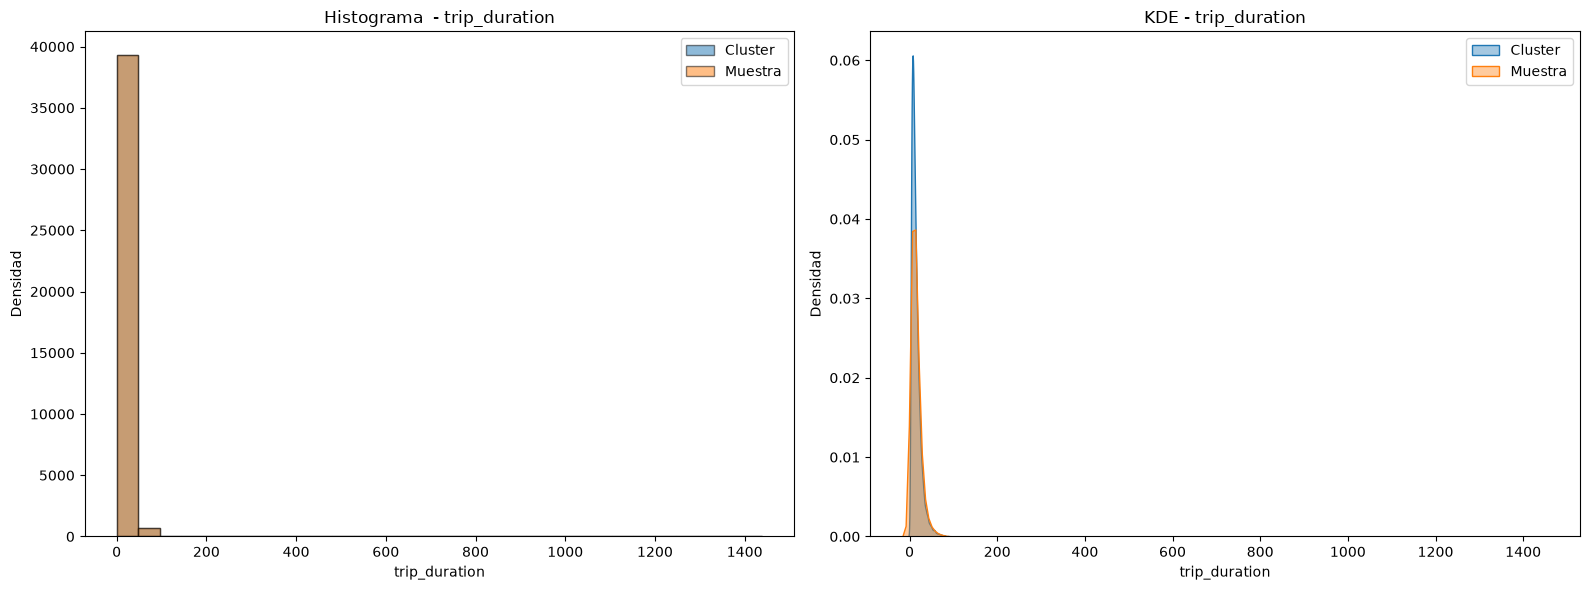

In [114]:
histograma_kde(df_dbs_c0,df,'trip_duration')

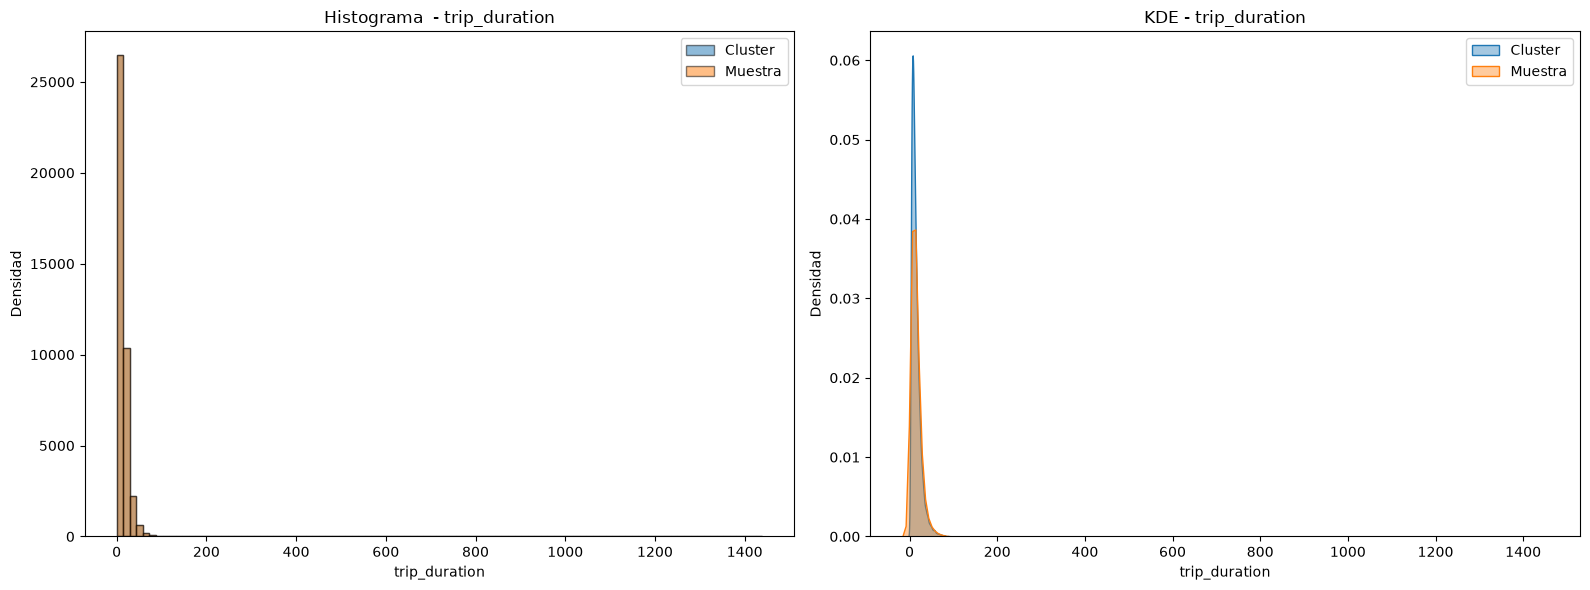

In [115]:
histograma_kde(df_dbs_c0,df,'trip_duration',99)

In [116]:
df_dbs_c0[df_dbs_c0['trip_duration'] > 120]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan


**Observaciones**
- El cluster 0 posee una concentración mayor en viajes con viajes inferiores a 2 horas, lo que indica que no captura viajes con duraciones extremas (tal como lo hace la distribución de la muestra analizada).

### **3.4.2 Cluster 1**

#### **Filtración Viajes Cluster 1**

In [117]:
df_dbs_c1 = df[df['k_cluster_dbscan'] == 1]
print("Tamaño Cluster: ", df_dbs_c1.shape[0])
print(f"Porcentaje del Total: {(df_dbs_c1.shape[0]/df.shape[0])*100:.2f}%")
df_dbs_c1.head()

Tamaño Cluster:  23
Porcentaje del Total: 0.06%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan
2882,2,2,N,1416.866667,Thursday,23,Friday,23,Manhattan,Manhattan,1.339752,0.056734,Noche,Noche,1,1
5000,2,5,N,1429.716667,Thursday,11,Friday,11,Manhattan,Manhattan,1.767160,0.074161,Mañana,Mañana,1,1
6368,2,5,N,1418.616667,Sunday,18,Monday,17,Manhattan,Manhattan,4.952053,0.209446,Noche,Tarde,1,1
9100,2,1,N,1436.066667,Monday,19,Tuesday,19,Manhattan,Manhattan,2.127525,0.088890,Noche,Noche,1,1
9922,2,1,N,1438.816667,Thursday,14,Friday,14,Manhattan,Manhattan,1.353500,0.056442,Tarde,Tarde,1,1


**Observaciones**
- El cluster 1 abarca menos del 1% de los viajes de la muestra analizada.

#### **id_vendor**

In [118]:
df_dbs_c1['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
1         NaN
2    0.001077
Name: count, dtype: float64

**Observaciones**
- Los viajes capturados por el cluster 1 son del proveedor 2.

#### **dia_semana**

In [119]:
tabla_cont(df_dbs_c1,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,0,0,3,0,0,0,0
Monday,0,0,0,0,0,4,0
Saturday,0,0,0,3,0,0,0
Sunday,0,3,0,0,0,0,0
Thursday,7,0,0,0,0,0,0
Tuesday,0,0,0,0,0,0,2
Wednesday,0,0,0,0,1,0,0


In [120]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- El cluster 1 solo abarca viajes que abarcaron 2 días seguidos.

#### **borough**

In [121]:
tabla_cont(df_dbs_c1,'borough_pickup','borough_dropoff')

borough_dropoff,Manhattan
borough_pickup,
Manhattan,23


In [122]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster 1 solo captura viajes realizados dentro de Manhattan

#### **franja_horaria**

In [123]:
tabla_cont(df_dbs_c1,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Mañana,Tarde,Noche
franja_horaria_pickup,,,
Mañana,2,0,0
Tarde,0,7,0
Noche,0,1,13


**Observaciones**
- La mayoria de viajes conservaron la franja horaria de inicio a fin. Como los viajes abarcaron dos días, se observa que presentaron tiempos de duración superiores a las 12 horas.

#### **store_and_fwd_flag**

In [124]:
df_dbs_c1['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.000578
Y         NaN
Name: count, dtype: float64

**Observaciones**
- Todas los viajes del cluster 1 fueron enviados al servidor sin ser almacenados localmente.

#### **passenger_count**

In [125]:
df_dbs_c1['passenger_count'].value_counts()

passenger_count
1    17
2     2
5     2
3     1
6     1
Name: count, dtype: int64

In [126]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

- La mayoría de viajes del cluster 1 fueron de 1 pasajero.

#### **distancia_haversine**

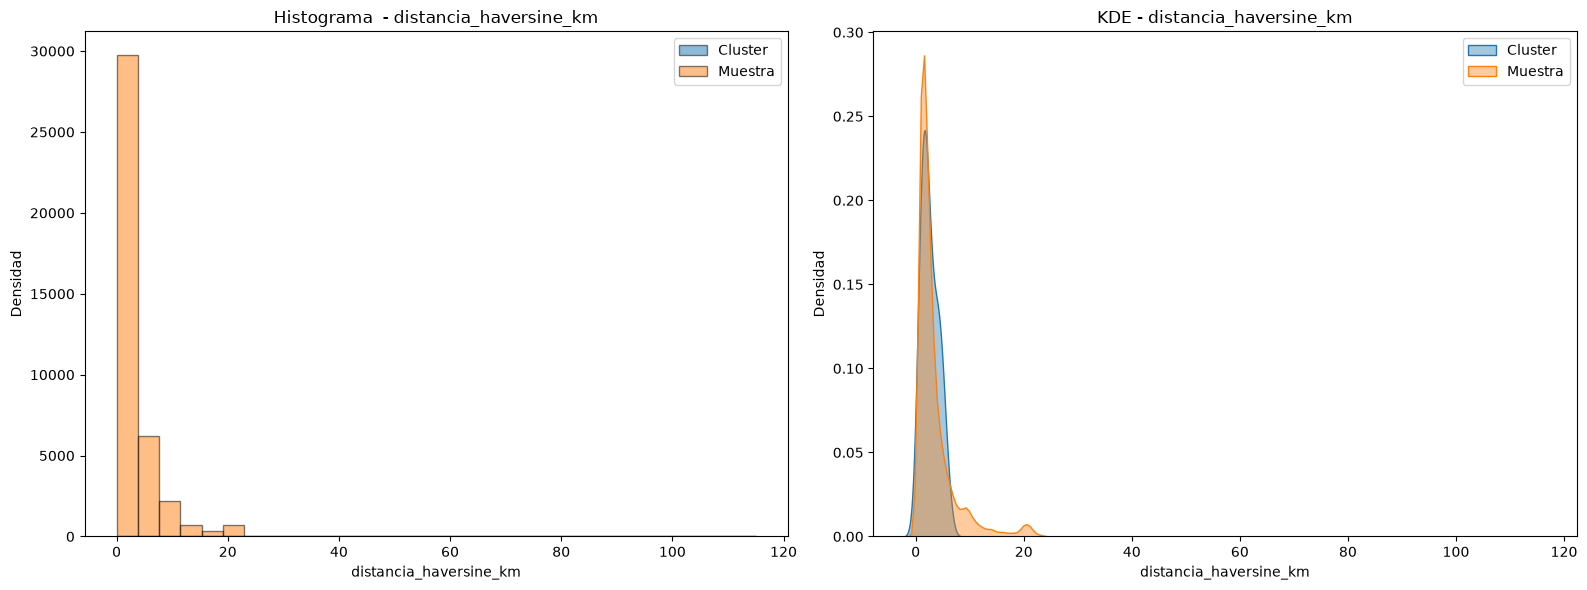

In [127]:
histograma_kde(df_dbs_c1,df,'distancia_haversine_km')

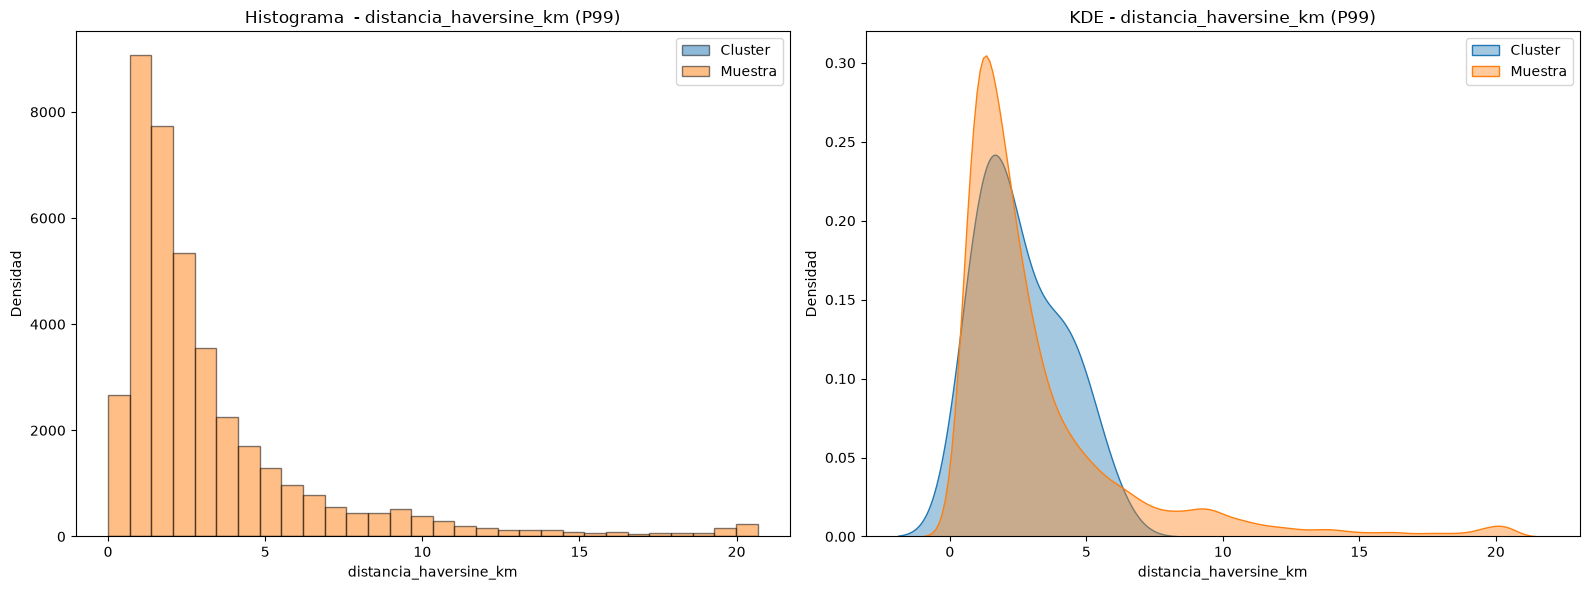

In [128]:
histograma_kde(df_dbs_c1,df,'distancia_haversine_km',30,99)

In [129]:
print("Min: ", df_dbs_c1['distancia_haversine_km'].min())
print("Max: ", df_dbs_c1['distancia_haversine_km'].max())

Min:  0.5652253757735466
Max:  5.881735629627811


**Observaciones**
- Los viajes del cluster 1 no poseen viajes con distancias extremas. Lo máximo son 5.9 kilómetros.

#### **velocidad_promedio_kmh**

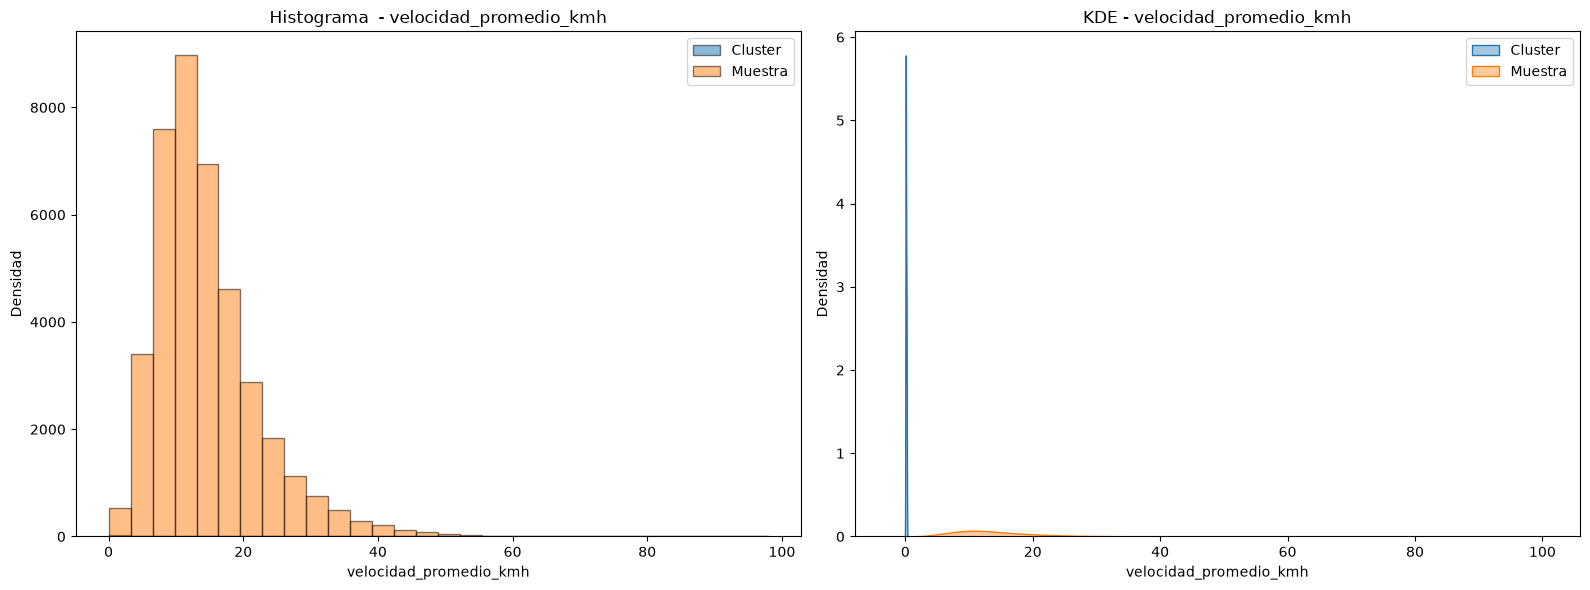

In [130]:
histograma_kde(df_dbs_c1,df,'velocidad_promedio_kmh')

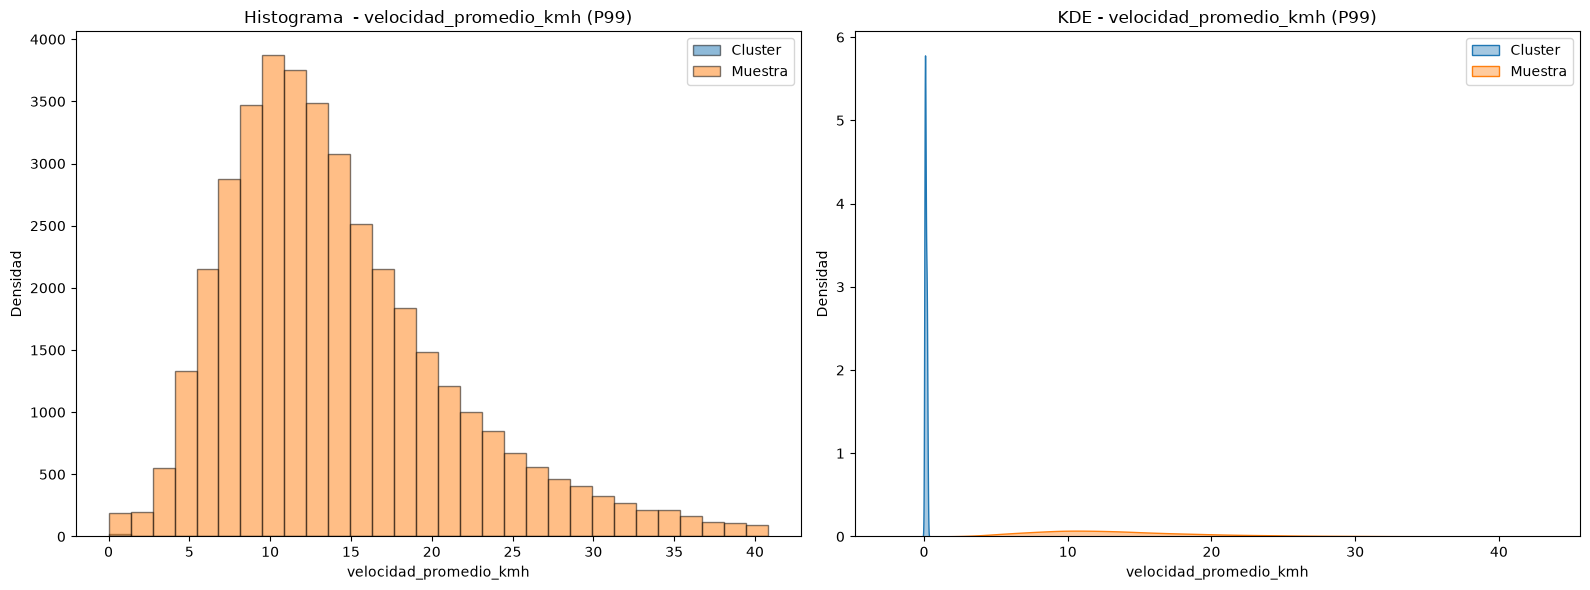

In [131]:
histograma_kde(df_dbs_c1,df,'velocidad_promedio_kmh',30,99)

In [132]:
print("Min: ", df_dbs_c1['velocidad_promedio_kmh'].min())
print("Max: ", df_dbs_c1['velocidad_promedio_kmh'].max())

Min:  0.0237781052034445
Max:  0.245706490904303


**Observaciones**
- Las velocidades promedio de los viajes fdel cluster 1 son muy pequeñas. Esto no indica directamente que sean erroneas, porque la velocidad promedio esta calculada como distancia total sobre la duración y no como el promedio de las distintas velocidades que el taxi pudo tomar en cierto tiempo.

#### **trip_duration**

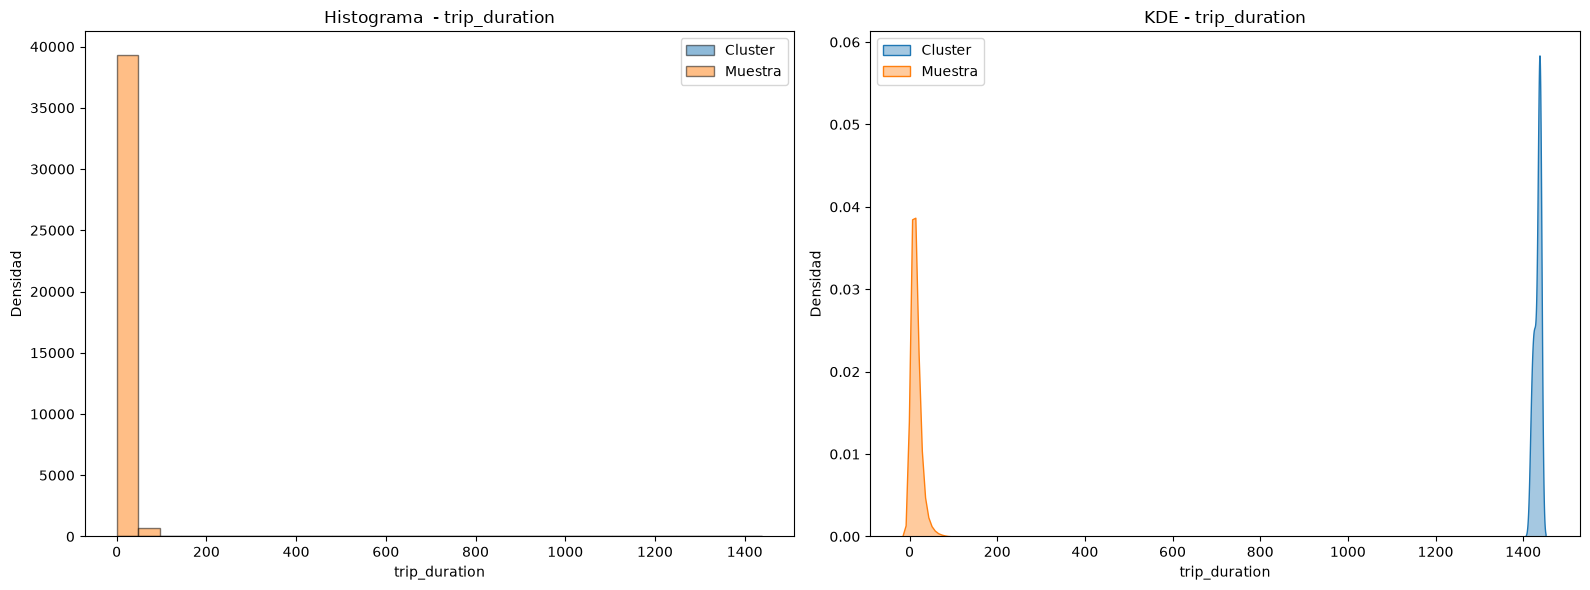

In [133]:
histograma_kde(df_dbs_c1,df,'trip_duration')

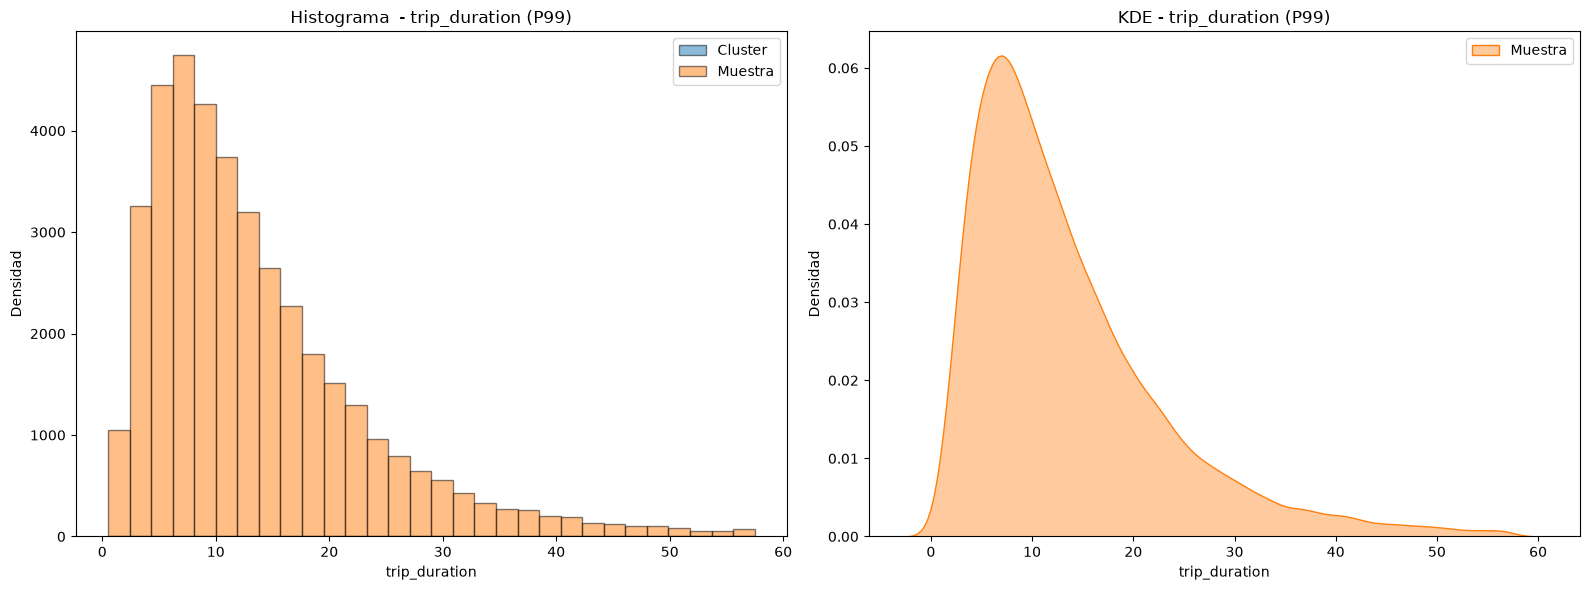

In [134]:
histograma_kde(df_dbs_c1,df,'trip_duration',30,99)

In [135]:
print("Min: ", df_dbs_c1['trip_duration'].min())
print("Max: ", df_dbs_c1['trip_duration'].max())

Min:  1416.8666666666666
Max:  1439.15


**Observaciones**
- Los viajes del cluster 1 abarcan duraciones extremas que superan las 23 horas.

### **3.4.5 Ruido**

#### **Filtración de Viajes Ruido**

In [136]:
df_dbs_ruido = df[df['k_cluster_dbscan'] == -1]
print("Tamaño Cluster: ", df_dbs_ruido.shape[0])
print(f"Porcentaje del Total: {(df_dbs_ruido.shape[0]/df.shape[0])*100:.2f}%")
df_dbs_ruido.head()

Tamaño Cluster:  42
Porcentaje del Total: 0.10%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan
1290,2,1,N,62.150000,Friday,18,Friday,19,Queens,Externo,38.822262,37.479255,Noche,Noche,3,-1
2088,2,1,N,119.850000,Friday,10,Friday,12,Manhattan,Manhattan,0.102031,0.051079,Mañana,Tarde,2,-1
2658,1,1,N,146.466667,Friday,3,Friday,5,Manhattan,Bronx,7.874975,3.225980,Madrugada,Madrugada,2,-1
3090,2,1,N,1438.783333,Thursday,11,Friday,11,Manhattan,Manhattan,5.427887,0.226353,Mañana,Mañana,1,-1
4831,2,1,N,1333.233333,Tuesday,9,Wednesday,7,Queens,Manhattan,3.355197,0.150995,Mañana,Mañana,1,-1


**Observaciones**
- Una proporción muy pequeña de la muestra fue identificada como ruido.

#### **vendor_id**

In [137]:
df_dbs_ruido['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.001593
1    0.000429
Name: count, dtype: float64

#### **dia_semana**

In [138]:
tabla_cont(df_dbs_ruido,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6,0,3,0,0,0,0
Monday,0,0,0,0,0,2,0
Saturday,0,0,3,6,0,0,0
Sunday,0,2,0,1,0,0,0
Thursday,4,0,0,0,5,0,0
Tuesday,0,0,0,0,0,4,3
Wednesday,0,0,0,0,2,0,1


**Observaciones**
- No se evidencia un patrón claro en el comportamiento de los viajes que fueron clasificados como ruido al segmentarlos por el día de la semana.

#### **borough**

In [139]:
tabla_cont(df_dbs_ruido,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,1,0,0,0,0,0
Brooklyn,0,1,0,0,0,0
Manhattan,1,1,6,15,4,0
Queens,1,0,8,3,0,1


#### **store_and_fwd_flag**

In [140]:
df_dbs_ruido['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.001056
Y         NaN
Name: count, dtype: float64

**Observaciones**
- Ninguno de los viajes clasificados como ruido fue registrado localmente previo a ser enviado al servidor.

#### **franja horaria**

In [141]:
tabla_cont(df_dbs_ruido,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,14,0,1,1
Mañana,0,5,1,0
Tarde,3,0,3,2
Noche,2,0,0,10


In [142]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- Algunos de los viajes clasificados como ruido poseen franjas de inicio muy separadas de las de finalización (como Madrugada-Noche).

#### **passenger_count**

In [143]:
df_dbs_ruido['passenger_count'].value_counts()

passenger_count
1    30
2     7
5     3
6     1
4     1
Name: count, dtype: int64

**Observaciones**
- La mayoria de los viajes clasificados como ruido presentaron 1 pasajero.

#### **distancia_haversine**

In [144]:
df_dbs_ruido['distancia_haversine_km']

1290      38.822262
2088       0.102031
2658       7.874975
3090       5.427887
4831       3.355197
5133       2.088489
5598       2.026132
6777      34.865902
8374       1.172894
10518     20.467905
12345      5.190411
13356      8.569507
13492      1.129300
15219     30.523513
15881     36.545612
17637      4.685589
18640     42.417873
22011      1.384541
22146     26.812014
22313     35.115484
22990     35.991943
23217      0.848645
26478      2.778798
26893      7.624020
26975      8.004052
27008      0.115236
28254      1.287576
29516     20.589134
30882      1.845079
31121     34.545351
31895     11.878190
36000      2.830949
36298     32.428074
36651      7.590252
36954      5.735387
37301     33.674105
37302     33.860007
37429     31.161481
37991      7.989197
38450     34.405905
39361      6.982474
39636    114.992275
Name: distancia_haversine_km, dtype: float64

**Observaciones**
- Existen algunas distancias muy elevadas en los viajes clasificados como ruido (por ejemplo:114 km), mientras que se observan distancias muy cortas como 0.11km

#### **velocidad_promedio_kmh**

In [145]:
df_dbs_ruido['velocidad_promedio_kmh']

1290     37.479255
2088      0.051079
2658      3.225980
3090      0.226353
4831      0.150995
5133      0.090400
5598      0.084525
6777     41.894943
8374      0.048907
10518     1.823918
12345     0.216668
13356     0.363478
13492     0.047244
15219    43.227634
15881    43.334717
17637     1.306695
18640    41.104803
22011     0.814436
22146    48.626323
22313    51.640417
22990    58.155742
23217     0.035776
26478     0.286474
26893     0.321041
26975     0.333978
27008     0.009595
28254     0.149049
29516     0.936461
30882     0.856185
31121    29.673887
31895     0.501666
36000     0.119086
36298    49.487523
36651     0.318967
36954     0.241693
37301    47.372715
37302    44.101311
37429    55.398188
37991     0.338338
38450    32.196844
39361     0.297113
39636    69.904119
Name: velocidad_promedio_kmh, dtype: float64

**Observaciones**
- La myaoria de velocidades promedio son muy bajas (casi 0), mientras que existen velocidades altas (como 70 km por hora).

#### **trip_duration**

In [146]:
df_dbs_ruido['trip_duration']

1290       62.150000
2088      119.850000
2658      146.466667
3090     1438.783333
4831     1333.233333
5133     1386.166667
5598     1438.250000
6777       49.933333
8374     1438.916667
10518     673.316667
12345    1437.333333
13356    1414.583333
13492    1434.216667
15219      42.366667
15881      50.600000
17637     215.150000
18640      61.916667
22011     102.000000
22146      33.083333
22313      40.800000
22990      37.133333
23217    1423.266667
26478     582.000000
26893    1424.866667
26975    1437.950000
27008     720.583333
28254     518.316667
29516    1319.166667
30882     129.300000
31121      69.850000
31895    1420.650000
36000    1426.333333
36298      39.316667
36651    1427.783333
36954    1423.800000
37301      42.650000
37302      46.066667
37429      33.750000
37991    1416.783333
38450      64.116667
39361    1410.066667
39636      98.700000
Name: trip_duration, dtype: float64

**Observaciones**
- Las duraciones de los viajes clasificados como ruido tienden a ser altas

In [147]:
df_dbs_ruido

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster,k_cluster_dbscan
1290,2,1,N,62.150000,Friday,18,Friday,19,Queens,Externo,38.822262,37.479255,Noche,Noche,3,-1
2088,2,1,N,119.850000,Friday,10,Friday,12,Manhattan,Manhattan,0.102031,0.051079,Mañana,Tarde,2,-1
2658,1,1,N,146.466667,Friday,3,Friday,5,Manhattan,Bronx,7.874975,3.225980,Madrugada,Madrugada,2,-1
3090,2,1,N,1438.783333,Thursday,11,Friday,11,Manhattan,Manhattan,5.427887,0.226353,Mañana,Mañana,1,-1
4831,2,1,N,1333.233333,Tuesday,9,Wednesday,7,Queens,Manhattan,3.355197,0.150995,Mañana,Mañana,1,-1
5133,2,1,N,1386.166667,Saturday,23,Sunday,22,Manhattan,Manhattan,2.088489,0.090400,Noche,Noche,1,-1
5598,2,1,N,1438.250000,Friday,3,Saturday,3,Manhattan,Manhattan,2.026132,0.084525,Madrugada,Madrugada,1,-1
6777,2,1,N,49.933333,Thursday,21,Thursday,22,Manhattan,Externo,34.865902,41.894943,Noche,Noche,3,-1
8374,2,1,N,1438.916667,Friday,7,Saturday,7,Manhattan,Manhattan,1.172894,0.048907,Mañana,Mañana,1,-1
10518,2,1,N,673.316667,Sunday,12,Monday,0,Manhattan,Queens,20.467905,1.823918,Tarde,Madrugada,3,-1


# **4. Conclusión y Tratamiento de Datos**

En conclusión, se probaron dos métodos de clusterización, con el fin de segmentar los viajes, evidenciar patrones, identificar ruido y proponer un tratamiento operativo. Los modelos implementados fueron K-means y DBSCAN.

En primera instancia, se realizó la clusterización con K-means, donde se probaron distintos valores k de clusteres, logrando identificar que el k=4 representaba una opción argumentable, debido a su desempeño en las métricas del índice de Silhouette, Davies-Bouldin, Calinski-Harabasz y la inercia.

De este modo, se identificó que el cluster 0  se caracteriza por porseer más de la mitad de los viajes de la muestra analizada, capturando más de la mitad de los viajes Manhattan-Manhattan y una cantidad ligeramente inferior a la mitad de los viajes Mahattan-Brooklyn. De la misma manera, solo expresa los viajes que iniciaron en las franjas tarde (12:00-5:59 pm) y Noche (6:00-11:59 pm), además de que expresa viajes con trayectorias inferiores a 20km y algunos con distancias extremadamente cortas.

Por otra parte, se evidenció que el clúster 1 abarca una porción casi insignificante de los datos, en su mayoría corresponden a viajes del proveedor dos y viajes que abarcan dos días, donde una buena parte corresponde a viajes que se iniciaron y finalizaron en Manhattan.

Asimismo, se notó que el cluster 2 es el segundo cluster más grande. Este abarca únicamente viajes que iniciaron y terminaron en el mismo dia, donde posee especialmente una cantidad relevante de viajes que iniciaron en Manhattan y terminaron el Brooklyn , Manhattan o Queens. Asimismo, posee un tamaño considerable de los viajes que se realizaron en las  franjas madrugada–madrugada, mañana–mañana, madrugada–mañana y mañana–tarde.

Para terminar, El cluster 3 es el tercer cluster más grande, caracterizado por abarcar una proporción grande de los viajes que iniciaron en Queens y terminaron en un municipio distintos, además de que los poseen distancias superiores a los 5 kilómetros y la mayor concentración de los tiempos de duración de estos viajes superan los 20 minutos.

Por otro lado, se realizó una clusterización utilizando DBSCAN, donde en primer lugar se probaron distintos tamaños de muestra y posteriormente distintos radios de vecindad, con el fin de obtener una configuración defendible que presentara un equilibrio en las métricas analizadas, que fueron el índice de Silhouette, Davies-Bouldin, Calinski-Harabasz y el porcentaje de ruido. Del mismo modo, se realizó un diagrama de k-distancia con k=10 vecinos, donde se identifico que existia una cantidad menor a 50 observaciones que presentaban una distancia elevada hacia el 10 vecino más cercano, por lo que probablemente iban as ser detectados como ruido. De este modo, se logró identificar que una configuración defendible para los parámetros $\epsilon$ y min_samples era 0.9 y 10 respectivamente. 

Conforme a lo anterior, se segmentaron los viajes en 2 clusteres principales y un segmento de ruido, donde se observó que el cluster 0 abarca casi el 99%. En su mayor parte no se evidenciaron patrones diferenciadores, excepto en la duración, donde se observa que no posee tiempos de duración extremos. De esta manera, el tiempo de duración de los viajes del clsuter fue inferior a 2 horas.

También, el clúster 1 abarca menos del 1 % de los viajes de la muestra analizada, se caracterizó por capturar viajes que abarcaron dos días y se realizaron dentro de Manhattan. Del mismo modo, la mayoriade est. La mayoria de estos viajes fue de 1 pasajero, las distancias no fueron extremas (máxino 5.9),  las velocidades promedio fueron muy pequeñas, pero los tiempos de duración superaron las 23 horas.

De la misma manera, los registros catalogados como ruido ocupan una porción insiginificante de la muestra, donde la mayoria de estos viajes fueron de 1 pasajero. Se identificó que estos viajes presentaban distancias demasiado cortas (por ejemplo: 0.11km) y muy largas (por ejemplo: 114km). Del mismo modo, las velocidades promedio presentaron valores cercanos a cero como velocidades elevadas como de 70 kilómetros por hora.

Finalmente, se propone asignar una flag a los registros clasificados como ruido por DBSCAN, con el fin de realizar una indagación interna en las bases de datos de la empresa y consultar el recorrido completo del taxi. De esta manera, será posible determinar si el comportamiento identificado corresponde a un error del sistema, de la plataforma o del conductor, o si, por el contrario, representa un viaje real con características atípicas.

Asimismo, con el propósito de extrapolar los patrones identificados en los registros clasificados como ruido hacia el conjunto total de viajes, se propone analizar las variables que caracterizan estos comportamientos, tales como distancias, velocidades y tiempos extremos. A partir de estos patrones, se podrán establecer reglas o criterios de detección que permitan identificar nuevos registros potencialmente anómalos dentro de la población de 1,5 millones de viajes. Esto permitiría ampliar el análisis más allá de los casos detectados inicialmente por DBSCAN y encontrar comportamientos anómalos que no necesariamente estén representados en la muestra analizada.
